# 📊 Influye la Industria en la Precisión de los Analistas Financieros - Evidencia de Influencia Estructural Relevante

## Trabajo de Fin de Grado - Business Analytics

**Código completo y documentado**

---

### Estructura del notebook:
3. **Configuración general y preparación de datos**
4. **Heterogeneidad industrial**
5. **Persistencia temporal**
6. **Análisis de robustez**


---
# 3️⃣ CONFIGURACIÓN GENERAL Y PREPARACIÓN DE DATOS


## 3.1. Imports de librerías

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import os
from pathlib import Path

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

from statsmodels.formula.api import ols

from scipy.stats import mstats, kruskal, pearsonr, spearmanr, linregress, wilcoxon
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

## 3.2. Configuración global

Configuración global, Constantes y parámetros, y Funciones auxiliares

In [ ]:
# 1. Configuración global
# Semilla aleatoria para reproducibilidad
SEED = 42
np.random.seed(SEED)

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
sns.set_context("paper", font_scale=1.2)

# Configuración de matplotlib en español
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Crear carpetas para resultados
Path('resultados_tfg').mkdir(exist_ok=True)
Path('resultados_tfg/tablas').mkdir(exist_ok=True)
Path('resultados_tfg/figuras').mkdir(exist_ok=True)

print("✅ Configuración global establecida")
print(f"📁 Carpetas creadas en: {os.getcwd()}/resultados_tfg/")

# 2. Constantes y parámetros
# Horizontes temporales a analizar
HORIZONTES_PRINCIPALES = [9, 12, 15]  # meses
HORIZONTES_ROBUSTEZ = [6, 18, 24]      # meses (para análisis de robustez)

# Nombres de industrias (mapeo para visualizaciones)
NOMBRES_INDUSTRIA = {
    1100: 'Non-Energy Minerals',
    1200: 'Producer Manufacturing',
    1300: 'Electronic Technology',
    1400: 'Consumer Durables',
    2100: 'Energy Minerals',
    2200: 'Process Industries',
    2300: 'Health Technology',
    2400: 'Consumer Non-Durables',
    3100: 'Industrial Services',
    3200: 'Commercial Services',
    3250: 'Distribution Services',
    3300: 'Technology Services',
    3350: 'Health Services',
    3400: 'Consumer Services',
    3500: 'Retail Trade',
    4600: 'Transportation',
    4700: 'Utilities',
    4800: 'Finance',
    4900: 'Communications',
    6000: 'Miscellaneous'
}

print(f"✅ Parámetros configurados")

# 3. Funciones auxiliares
def guardar_figura(fig, nombre, dpi=300):
    """
    Guarda una figura de matplotlib en la carpeta de resultados.

    Parámetros:
    -----------
    fig : matplotlib.figure.Figure
        Figura a guardar
    nombre : str
        Nombre del archivo (sin extensión)
    dpi : int, default=300
        Resolución de la imagen
    """
    filepath = f'resultados_tfg/figuras/{nombre}.png'
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"📊 Figura guardada: {filepath}")

def guardar_tabla(df, nombre, formato='excel'):
    """
    Guarda un DataFrame como tabla en la carpeta de resultados.

    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a guardar
    nombre : str
        Nombre del archivo (sin extensión)
    formato : str, default='excel'
        Formato de salida ('excel' o 'csv')
    """
    if formato == 'excel':
        filepath = f'resultados_tfg/tablas/{nombre}.xlsx'
        df.to_excel(filepath, index=True, engine='openpyxl')
    else:
        filepath = f'resultados_tfg/tablas/{nombre}.csv'
        df.to_csv(filepath, index=True)

    print(f"📋 Tabla guardada: {filepath}")

def formatear_pvalor(p):
    """
    Formatea un p-valor según convenciones académicas.

    Parámetros:
    -----------
    p : float
        P-valor

    Retorna:
    --------
    str : P-valor formateado con asteriscos de significancia
    """
    if pd.isna(p):
        return '-'

    if p < 0.001:
        return '< 0.001***'
    elif p < 0.01:
        return f'{p:.3f}**'
    elif p < 0.05:
        return f'{p:.3f}*'
    else:
        return f'{p:.3f}'

print("✅ Funciones auxiliares definidas")

✅ Configuración global establecida
📁 Carpetas creadas en: /content/resultados_tfg/


## 3.3. Carga de datos

Carga, limpieza y validación de datos

In [ ]:
# Cargar desde Excel
df_raw = pd.read_excel('/content/DATOS_TRABAJADOS.xlsx')
# Verificar columnas
columnas_necesarias = ['ticker', 'date', 'ison_univ', 'P_PRICE', 'target', 'Retorno', 'FREF_ENTITY_FACTSET_INDUSTRY']
columnas_faltantes = set(columnas_necesarias) - set(df_raw.columns)
if columnas_faltantes:
  print(f"⚠️ Faltan columnas: {columnas_faltantes}")
else:
  print("✅ Columnas OK")

print(f"📊 Datos cargados: {len(df_raw):,} filas")
df_raw.head()

✅ Columnas OK
📊 Datos cargados: 788,220 filas


,date,symbol,ison_univ,company_name,ticker,target,P_PRICE,Retorno,FREF_ENTITY_FACTSET_INDUSTRY
0,2020-11-17,00105510,True,Aflac Incorporated,AFL-US,42.7000,43.00,0.115657,4800.0
1,2020-11-17,00130H10,True,AES Corporation,AES-US,22.6875,21.35,0.093770,4700.0
2,2020-11-17,00206R10,True,AT&T Inc,T-US,23.5373,29.03,0.207126,4900.0
3,2020-11-17,00282410,True,Abbott Laboratories,ABT-US,120.0620,113.06,-0.536644,2300.0
4,2020-11-17,00287Y10,True,"AbbVie, Inc.",ABBV-US,111.4500,99.21,0.864172,2300.0


In [ ]:
# Convertir fecha a datetime
df_raw['date'] = pd.to_datetime(df_raw['date'], errors='coerce')
df_raw['month'] = df_raw['date'].dt.to_period('M')

# Eliminar filas con missing en variables clave
print(f"Filas antes: {len(df_raw):,}")
df_clean = df_raw.dropna(subset=['FREF_ENTITY_FACTSET_INDUSTRY', 'P_PRICE', 'target']).copy()
print(f"Filas después: {len(df_clean):,}")
print(f"Eliminadas: {len(df_raw)-len(df_clean):,} ({(len(df_raw)-len(df_clean))/len(df_raw)*100:.1f}%)")

Filas antes: 788,220
Filas después: 739,314
Eliminadas: 48,906 (6.2%)


## 3.4. Transformación a frecuencia mensual

Transformación a frecuencia mensual y estadísticas descriptivas iniciales

In [ ]:
# Ordenar y tomar último día del mes
df_monthly = (df_clean.sort_values(['ticker', 'date']).groupby(['ticker', 'month'], as_index=False).last())
print(f"✅ Frecuencia mensual")
print(f"   - Filas: {len(df_monthly):,}")
print(f"   - Empresas: {df_monthly['ticker'].nunique()}")
print(f"   - Meses: {df_monthly['month'].nunique()}")
print(f"   - Industrias: {df_monthly['FREF_ENTITY_FACTSET_INDUSTRY'].nunique()}")
# Verificar duplicados
assert df_monthly.duplicated(['ticker', 'month']).sum() == 0
df_monthly.head()

✅ Frecuencia mensual
   - Filas: 34,596
   - Empresas: 598
   - Meses: 61
   - Industrias: 20


,ticker,month,date,symbol,ison_univ,company_name,target,P_PRICE,Retorno,FREF_ENTITY_FACTSET_INDUSTRY
0,A-US,2020-11,2020-11-30,00846U10,True,"Agilent Technologies, Inc.",118.4000,116.9000,2.4630,2300.0000
1,A-US,2020-12,2020-12-31,00846U10,True,"Agilent Technologies, Inc.",122.7500,118.4900,0.9370,2300.0000
2,A-US,2021-01,2021-01-29,00846U10,True,"Agilent Technologies, Inc.",125.7060,120.1700,-1.1435,2300.0000
3,A-US,2021-02,2021-02-26,00846U10,True,"Agilent Technologies, Inc.",138.6470,122.0700,-0.0246,2300.0000
4,A-US,2021-03,2021-03-31,00846U10,True,"Agilent Technologies, Inc.",139.5290,127.1400,1.8424,2300.0000


In [ ]:
# Estadísticas descriptivas iniciales
# Cobertura temporal
meses_por_emp = df_monthly.groupby('ticker')['month'].nunique()
print("COBERTURA TEMPORAL")
print("="*50)
print(f"Media meses: {meses_por_emp.mean():.1f}")
print(f"Empresas con cobertura completa: {(meses_por_emp == df_monthly['month'].nunique()).sum()}")
print(meses_por_emp.describe())

# Distribución industrias
print("\nDISTRIBUCIÓN INDUSTRIAS")
print("="*50)
print(df_monthly['FREF_ENTITY_FACTSET_INDUSTRY'].value_counts().sort_index())

# Añadir nombres de industria
df_monthly['industria_nombre'] = df_monthly['FREF_ENTITY_FACTSET_INDUSTRY'].map(NOMBRES_INDUSTRIA)

COBERTURA TEMPORAL
Media meses: 57.9
Empresas con cobertura completa: 534
count   598.0000
mean     57.8528
std      10.9510
min       2.0000
25%      61.0000
50%      61.0000
75%      61.0000
max      61.0000
Name: month, dtype: float64

DISTRIBUCIÓN INDUSTRIAS
FREF_ENTITY_FACTSET_INDUSTRY
1100.0000     366
1200.0000    2209
1300.0000    3237
1400.0000     893
2100.0000    1064
2200.0000    1516
2300.0000    3027
2400.0000    2313
3100.0000     847
3200.0000     906
3250.0000     549
3300.0000    3570
3350.0000     736
3400.0000    1878
3500.0000    1757
4600.0000    1050
4700.0000    1938
4800.0000    6438
4900.0000     244
6000.0000      58
Name: count, dtype: int64


## 3.5. Sesgo ex-ante (Bias₀)
**Fórmula:** `Bias₀ = (Target_t / Price_t) - 1`

Mide el optimismo/pesimismo del consenso en el momento t.

SESGO EX-ANTE (Bias₀)
count   34596.0000
mean        0.3129
std        11.0332
min        -0.8649
1%         -0.1575
5%         -0.0445
25%         0.0502
50%         0.1175
75%         0.2043
95%         0.3999
99%         0.6553
max      1202.0075
Name: bias_0, dtype: float64
📊 Figura guardada: resultados_tfg/figuras/Fig01_distribucion_sesgo_exante.png


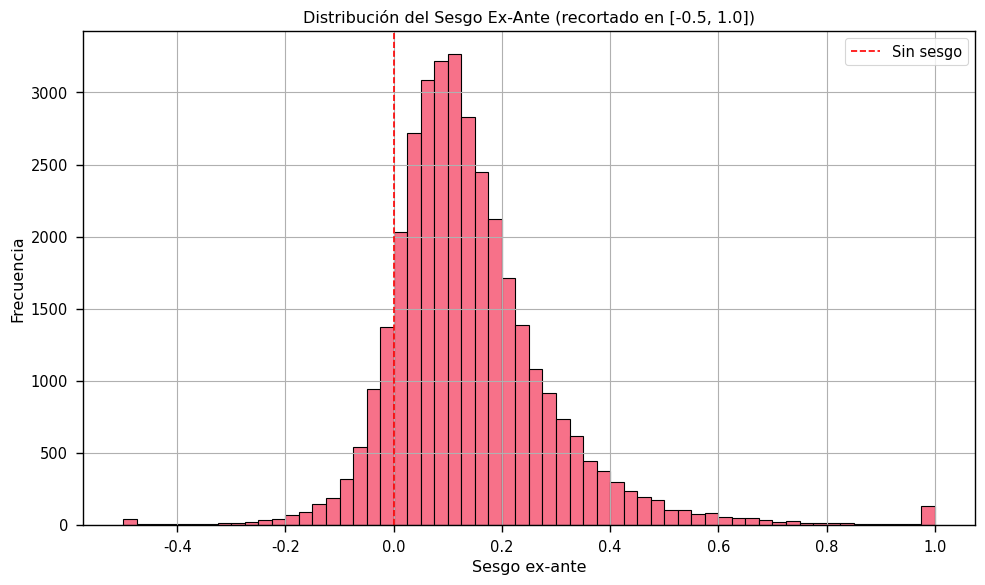


✅ Variable 'bias_0' creada


In [ ]:
# Calcular sesgo ex-ante
df_monthly['bias_0'] = df_monthly['target'] / df_monthly['P_PRICE'] - 1
print("SESGO EX-ANTE (Bias₀)")
print("="*50)
print(df_monthly['bias_0'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

# Histograma
fig, ax = plt.subplots(figsize=(10, 6))
df_monthly['bias_0'].clip(-0.5, 1.0).hist(bins=60, ax=ax, edgecolor='black')
ax.set_xlabel('Sesgo ex-ante')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del Sesgo Ex-Ante (recortado en [-0.5, 1.0])')
ax.axvline(0, color='red', linestyle='--', label='Sin sesgo')
ax.legend()
plt.tight_layout()

guardar_figura(fig, 'Fig01_distribucion_sesgo_exante')
plt.show()
print(f"\n✅ Variable 'bias_0' creada")

## 3.6. Sesgo y Error ex-post
**Para cada horizonte h ∈ {9, 12, 15} meses:**
- `bias_forward_h = (Target_t / Price_t+h) - 1`
- `error_abs_h = |bias_forward_h|`

Mide la precisión predictiva.

In [ ]:
# Construction of forward variables
# Combine principal and robustness horizons for comprehensive variable creation
all_horizons_to_create = sorted(list(set(HORIZONTES_PRINCIPALES + HORIZONTES_ROBUSTEZ)))

for h in all_horizons_to_create:
  # Precio futuro (shift negativo)
  df_monthly[f'price_fwd_{h}m'] = df_monthly.groupby('ticker')['P_PRICE'].shift(-h)
  # Sesgo forward
  df_monthly[f'bias_fwd_{h}m'] = df_monthly['target'] / df_monthly[f'price_fwd_{h}m'] - 1
  # Error absoluto
  df_monthly[f'error_abs_{h}m'] = df_monthly[f'bias_fwd_{h}m'].abs()

  # Resumen
  print(f"\nHORIZONTE {h} MESES")
  print("="*50)
  print(f"N obs válidas: {df_monthly[f'error_abs_{h}m'].notna().sum():,}")
  print(df_monthly[f'error_abs_{h}m'].describe(percentiles=[.01,.05,.5,.95,.99]))
  print(f"\n✅ Variables forward creadas para h = {h}")


HORIZONTE 6 MESES
N obs válidas: 31,024
count   31024.0000
mean        0.5601
std        20.3384
min         0.0000
1%          0.0024
5%          0.0128
50%         0.1471
95%         0.7046
99%         1.4706
max      2352.5768
Name: error_abs_6m, dtype: float64

✅ Variables forward creadas para h = 6

HORIZONTE 9 MESES
N obs válidas: 29,253
count   29253.0000
mean        0.7217
std        26.9023
min         0.0000
1%          0.0029
5%          0.0151
50%         0.1733
95%         0.8250
99%         1.8759
max      2867.5177
Name: error_abs_9m, dtype: float64

✅ Variables forward creadas para h = 9

HORIZONTE 12 MESES
N obs válidas: 27,493
count   27493.0000
mean        0.9472
std        38.9206
min         0.0000
1%          0.0036
5%          0.0176
50%         0.1925
95%         0.9326
99%         2.2555
max      4314.9184
Name: error_abs_12m, dtype: float64

✅ Variables forward creadas para h = 12

HORIZONTE 15 MESES
N obs válidas: 25,740
count   25740.0000
mean        1.0901

---
# 4️⃣ HETEROGENEIDAD INDUSTRIAL



## 4.1. Rankings de industrias por error mediano
Para cada horizonte temporal.

In [ ]:
# Función para calcular rankings
def calcular_ranking_industrias(df, horizonte):
  """Calcula ranking de industrias por error mediano."""
  col_error = f'error_abs_{horizonte}m'
  ranking = (df.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_error].agg(['median', 'mean', 'std', 'count']).sort_values('median', ascending=False).reset_index())
  ranking['industria_nombre'] = ranking['FREF_ENTITY_FACTSET_INDUSTRY'].map(NOMBRES_INDUSTRIA)
  ranking['rank'] = range(1, len(ranking)+1)
  return ranking

# Calcular para horizonte principal (12m)
ranking_12m = calcular_ranking_industrias(df_monthly, 12)
print("RANKING INDUSTRIAS (12 meses)")
print("="*70)
print(ranking_12m[['rank', 'industria_nombre', 'median', 'mean', 'count']].to_string(index=False))
# Gap económico
gap = ranking_12m['median'].iloc[0] - ranking_12m['median'].iloc[-1]
print(f"\n📊 Gap top-bottom: {gap:.4f} ({gap*100:.2f} puntos porcentuales)")
# Guardar tabla
guardar_tabla(ranking_12m, 'Tabla_Ranking_Industrias_12m')

RANKING INDUSTRIAS (12 meses)
 rank       industria_nombre  median   mean  count
    1      Consumer Durables  0.2749 0.3496    710
    2      Consumer Services  0.2357 0.4263   1495
    3     Process Industries  0.2322 0.3382   1214
    4        Energy Minerals  0.2282 0.2706    845
    5         Communications  0.2194 0.5273    196
    6      Health Technology  0.2192 0.3522   2400
    7    Commercial Services  0.2176 0.4281    714
    8         Transportation  0.2119 0.3151    834
    9           Retail Trade  0.2106 0.3556   1409
   10  Electronic Technology  0.2028 0.2964   2554
   11    Technology Services  0.2013 0.4882   2826
   12 Producer Manufacturing  0.1892 0.3267   1753
   13    Non-Energy Minerals  0.1891 0.2203    294
   14                Finance  0.1829 3.6285   5104
   15          Miscellaneous  0.1742 0.2160     46
   16  Consumer Non-Durables  0.1705 0.3023   1845
   17    Industrial Services  0.1641 0.2140    679
   18  Distribution Services  0.1557 0.1703    441
 

## 4.2. Visualización: Boxplots por industria

 Crear boxplot comparativo de error por industria
- Eje X: industrias ordenadas por mediana
- Eje Y: error absoluto
- Colores diferenciados
- Guardar como "Fig02_boxplot_error_industrias"



BOXPLOT: ERROR ABSOLUTO POR INDUSTRIA


/tmp/ipykernel_5032/166091369.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


📊 Figura guardada: resultados_tfg/figuras/Fig02_boxplot_error_industrias.png


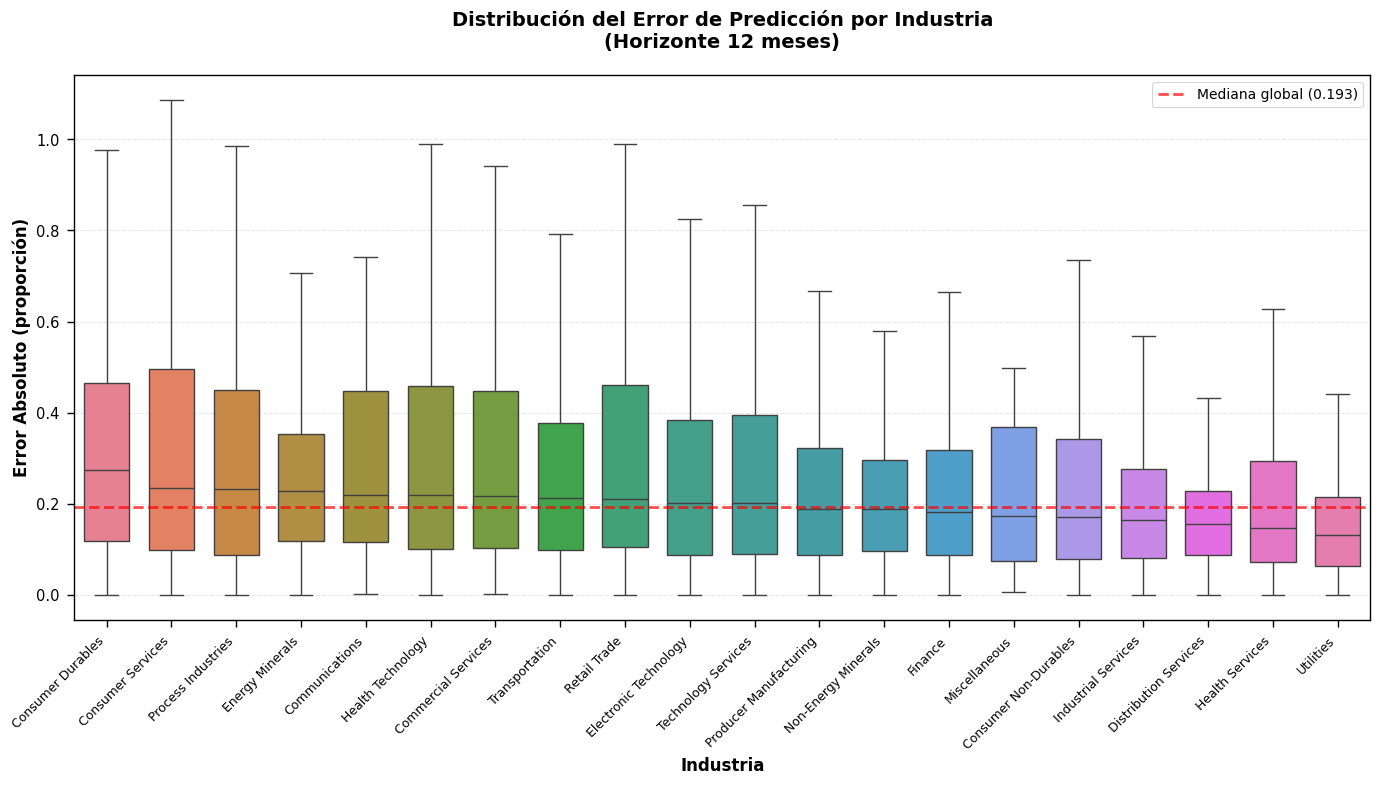

✅ Boxplot guardado
   - Industrias ordenadas: peor → mejor precisión
   - Mediana global: 0.193


In [ ]:
# ============================================================================
# 4.2. VISUALIZACIÓN: Boxplots por Industria
# ============================================================================

print("\n" + "="*70)
print("BOXPLOT: ERROR ABSOLUTO POR INDUSTRIA")
print("="*70)

# Preparar datos para boxplot (h=12m)
df_boxplot = df_monthly[['FREF_ENTITY_FACTSET_INDUSTRY', 'industria_nombre', 'error_abs_12m']].dropna()

# Ordenar industrias por mediana de error
orden_industrias = (df_boxplot.groupby('industria_nombre')['error_abs_12m']
                    .median()
                    .sort_values(ascending=False)
                    .index.tolist())

# Crear figura
fig, ax = plt.subplots(figsize=(14, 8))

# Boxplot con seaborn (más fácil de personalizar)
sns.boxplot(
    data=df_boxplot,
    x='industria_nombre',
    y='error_abs_12m',
    order=orden_industrias,
    palette='husl',  # Paleta de colores diversa
    ax=ax,
    showfliers=False,  # No mostrar outliers para claridad (opcional)
    width=0.7
)

# Personalización
ax.set_xlabel('Industria', fontsize=12, fontweight='bold')
ax.set_ylabel('Error Absoluto (proporción)', fontsize=12, fontweight='bold')
ax.set_title('Distribución del Error de Predicción por Industria\n(Horizonte 12 meses)',
             fontsize=14, fontweight='bold', pad=20)

# Rotar etiquetas eje x
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

# Grid horizontal para facilitar lectura
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Añadir línea horizontal en mediana global
mediana_global = df_boxplot['error_abs_12m'].median()
ax.axhline(y=mediana_global, color='red', linestyle='--', linewidth=2,
           alpha=0.7, label=f'Mediana global ({mediana_global:.3f})')

ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
guardar_figura(fig, 'Fig02_boxplot_error_industrias')
plt.show()

print(f"✅ Boxplot guardado")
print(f"   - Industrias ordenadas: peor → mejor precisión")
print(f"   - Mediana global: {mediana_global:.3f}")

## 4.3. Heatmap: Error por industria × horizonte
**ESPECIFICACIONES:**
- Filas: 20 industrias
- Columnas: Horizontes (9m, 12m, 15m)
- Valores: Error absoluto mediano
- Colormap: Divergente (bajo=verde, alto=rojo)
- Guardar como "Fig03_heatmap_industria_horizonte"


HEATMAP: ERROR POR INDUSTRIA × HORIZONTE TEMPORAL
📊 Figura guardada: resultados_tfg/figuras/Fig03_heatmap_industria_horizonte.png


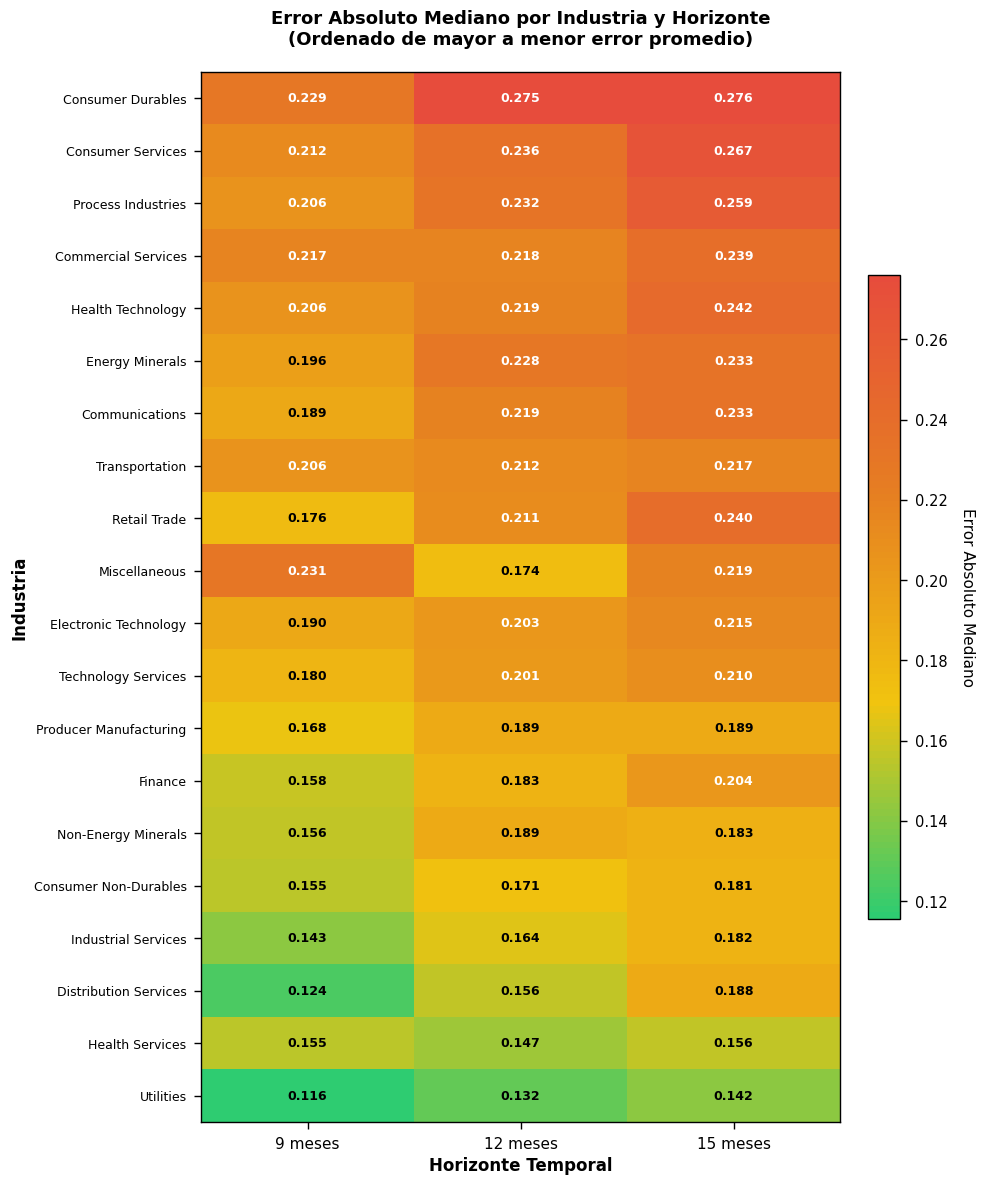

✅ Heatmap guardado
   - Filas: 20 industrias
   - Columnas: 3 horizontes
   - Rango de error: [0.116, 0.276]

📊 TABLA NUMÉRICA:
----------------------------------------------------------------------
             industria     9m    12m    15m
     Consumer Durables 0.2292 0.2749 0.2759
     Consumer Services 0.2120 0.2357 0.2667
    Process Industries 0.2063 0.2322 0.2587
   Commercial Services 0.2170 0.2176 0.2389
     Health Technology 0.2063 0.2192 0.2423
       Energy Minerals 0.1961 0.2282 0.2328
        Communications 0.1894 0.2194 0.2333
        Transportation 0.2064 0.2119 0.2168
          Retail Trade 0.1760 0.2106 0.2403
         Miscellaneous 0.2308 0.1742 0.2191
 Electronic Technology 0.1905 0.2028 0.2149
   Technology Services 0.1802 0.2013 0.2098
Producer Manufacturing 0.1681 0.1892 0.1891
               Finance 0.1577 0.1829 0.2035
   Non-Energy Minerals 0.1559 0.1891 0.1832
 Consumer Non-Durables 0.1545 0.1705 0.1814
   Industrial Services 0.1427 0.1641 0.1819
 Distribu

In [ ]:
# ============================================================================
# 4.3. HEATMAP: Error por Industria × Horizonte
# ============================================================================

print("\n" + "="*70)
print("HEATMAP: ERROR POR INDUSTRIA × HORIZONTE TEMPORAL")
print("="*70)

# Horizontes a incluir (los 3 principales)
horizontes_heatmap = [9, 12, 15]

# Calcular error mediano por industria y horizonte
datos_heatmap = []

for h in horizontes_heatmap:
    col_error = f'error_abs_{h}m'

    if col_error in df_monthly.columns:
        error_por_industria = (df_monthly.groupby('industria_nombre')[col_error]
                               .median()
                               .reset_index())
        error_por_industria.columns = ['industria', f'{h}m']
        datos_heatmap.append(error_por_industria)

# Merge todas las columnas
df_heatmap = datos_heatmap[0]
for i in range(1, len(datos_heatmap)):
    df_heatmap = df_heatmap.merge(datos_heatmap[i], on='industria')

# Ordenar industrias por error promedio (peor → mejor)
df_heatmap['promedio'] = df_heatmap[[f'{h}m' for h in horizontes_heatmap]].mean(axis=1)
df_heatmap = df_heatmap.sort_values('promedio', ascending=False).reset_index(drop=True)

# Preparar matriz para heatmap (sin columna industria y promedio)
matriz_heatmap = df_heatmap[[f'{h}m' for h in horizontes_heatmap]].values
industrias_labels = df_heatmap['industria'].values

# Crear figura
fig, ax = plt.subplots(figsize=(10, 12))

# Crear heatmap
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Colormap personalizado: verde (bajo) → amarillo → rojo (alto)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']  # Verde → Amarillo → Naranja → Rojo
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

# Heatmap
im = ax.imshow(matriz_heatmap, cmap=cmap, aspect='auto',
               vmin=matriz_heatmap.min(), vmax=matriz_heatmap.max())

# Configurar ejes
ax.set_xticks(np.arange(len(horizontes_heatmap)))
ax.set_yticks(np.arange(len(industrias_labels)))
ax.set_xticklabels([f'{h} meses' for h in horizontes_heatmap], fontsize=11)
ax.set_yticklabels(industrias_labels, fontsize=9)

# Título y etiquetas
ax.set_xlabel('Horizonte Temporal', fontsize=12, fontweight='bold')
ax.set_ylabel('Industria', fontsize=12, fontweight='bold')
ax.set_title('Error Absoluto Mediano por Industria y Horizonte\n(Ordenado de mayor a menor error promedio)',
             fontsize=13, fontweight='bold', pad=20)

# Añadir valores en cada celda
for i in range(len(industrias_labels)):
    for j in range(len(horizontes_heatmap)):
        valor = matriz_heatmap[i, j]
        color_texto = 'white' if valor > matriz_heatmap.mean() else 'black'
        text = ax.text(j, i, f'{valor:.3f}',
                      ha="center", va="center",
                      color=color_texto, fontsize=9, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Error Absoluto Mediano', rotation=270, labelpad=20, fontsize=11)

plt.tight_layout()
guardar_figura(fig, 'Fig03_heatmap_industria_horizonte')
plt.show()

print(f"✅ Heatmap guardado")
print(f"   - Filas: {len(industrias_labels)} industrias")
print(f"   - Columnas: {len(horizontes_heatmap)} horizontes")
print(f"   - Rango de error: [{matriz_heatmap.min():.3f}, {matriz_heatmap.max():.3f}]")

# Mostrar tabla numérica
print(f"\n📊 TABLA NUMÉRICA:")
print("-"*70)
print(df_heatmap[['industria'] + [f'{h}m' for h in horizontes_heatmap]].to_string(index=False))

## 4.4. Test de Kruskal-Wallis (no paramétrico)
H₀: Todas las industrias tienen la misma distribución de error

In [ ]:
# Test Kruskal-Wallis para cada horizonte
resultados_kw = {}
for h in HORIZONTES_PRINCIPALES:
  col = f'error_abs_{h}m'
  # Separar por industria
  grupos = [grupo[col].dropna().values for _, grupo in df_monthly.groupby('FREF_ENTITY_FACTSET_INDUSTRY')]
  # Test
  stat, pval = kruskal(*grupos)
  resultados_kw[h] = {'H': stat, 'p': pval}
  print(f"\nKRUSKAL-WALLIS (h={h}m)")
  print("="*50)
  print(f"H-statistic: {stat:.2f}")
  print(f"p-value: {formatear_pvalor(pval)}")
  print(f"p-value: {pval}")

# Tabla resumen
df_kw = pd.DataFrame(resultados_kw).T
df_kw.columns = ['H-statistic', 'p-value']
guardar_tabla(df_kw, 'Tabla_Test_Kruskal_Wallis')
print("\n✅ Tests Kruskal-Wallis completados")


KRUSKAL-WALLIS (h=9m)
H-statistic: 771.77
p-value: < 0.001***
p-value: 2.1393687592147178e-151

KRUSKAL-WALLIS (h=12m)
H-statistic: 638.30
p-value: < 0.001***
p-value: 4.102420699602889e-123

KRUSKAL-WALLIS (h=15m)
H-statistic: 590.28
p-value: < 0.001***
p-value: 5.656632735336352e-113
📋 Tabla guardada: resultados_tfg/tablas/Tabla_Test_Kruskal_Wallis.xlsx

✅ Tests Kruskal-Wallis completados


## 4.5. Efectos fijos por industria

Se estima el modelo de efectos fijos
agregando los datos a nivel industria-mes.

Para cada par industria-mes se calcula el error absoluto mediano a 12
meses, eliminando el ruido idiosincrático empresa-nivel antes de estimar.
Miscellaneous se excluye por los mismos motivos que en el clustering:
una única empresa no es representativa de un sector. Se mantiene HC3
para consistencia con el modelo empresa-mes.


EFECTOS FIJOS AGREGADOS: Industria-Mes

📊 DATOS AGREGADOS:
   N observaciones (industria-mes): 931
   N industrias: 19
   N meses: 49
   Empresas promedio por celda: 29.5
   Min empresas por celda: 4
   Max empresas por celda: 107

✅ Datos agregados listos

🔄 Estimando modelo agregado con HC3...
✅ Modelo estimado

🔍 TEST DE WALD — EFECTOS INDUSTRIA (válido con HC3):
   H0: Todos los β_industria = 0
   F-statistic: 13.7000
   p-value:     0.0000
   ✅ Significativo al 0.1%
R² within (por mes, mide efecto industria): 0.2412 (24.12%)

📊 RESULTADOS DETALLADOS: EFECTOS FIJOS DE INDUSTRIA (Agregado)
Industria de referencia: Commercial Services
----------------------------------------------------------------------
                Industria       β     EE       t  p-value Sig.
                Utilities -0.1199 0.0174 -6.9009   0.0000  ***
          Health Services -0.0950 0.0181 -5.2383   0.0000  ***
    Distribution Services -0.0942 0.0161 -5.8592   0.0000  ***
      Industrial Services -0.08

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/tmp/ipykernel_5032/1227982837.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"   F-statistic: {float(wald_test.statistic):.4f}")


📊 Figura guardada: resultados_tfg/figuras/Fig04b_regresion_efectos_fijos_agregado.png


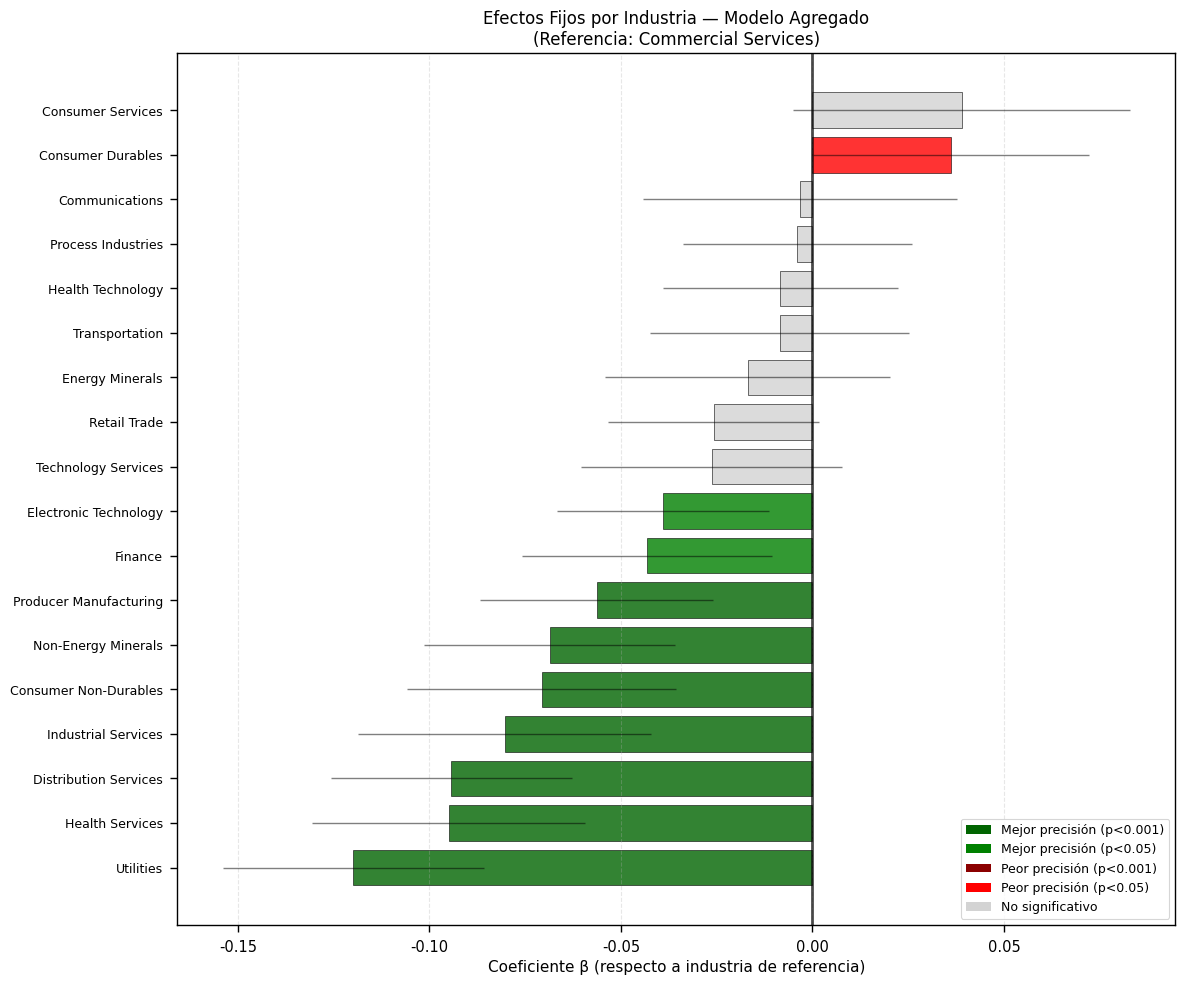

✅ Visualización guardada: Fig04b_regresion_efectos_fijos_agregado.png

✅ MODELO AGREGADO COMPLETADO


In [ ]:
# ============================================================================
# 4.5. REGRESIÓN CON EFECTOS FIJOS — INDUSTRIA-MES
# ============================================================================
# Dado que la pregunta de investigación es sobre diferencias entre industrias,
# la unidad natural de análisis es la industria, no la empresa. Se agrega
# el error absoluto a nivel industria-mes calculando la mediana de cada
# sector en cada período. Este enfoque elimina el ruido idiosincrático
# empresa-nivel irrelevante para la pregunta, y asegura que el modelo mide
# directamente el comportamiento sistemático de cada industria.
#
# Miscellaneous excluida: única empresa, no representativa de un sector.
# Errores HC3: corrección de heterocedasticidad. Errores clusterizados
# por industria serían más apropiados para correlación serial, pero con
# solo 19 industrias el número de clusters es insuficiente para inferencia
# fiable (umbral recomendado ~50).
# ============================================================================

print("\n" + "="*70)
print("EFECTOS FIJOS AGREGADOS: Industria-Mes")
print("="*70)

# --- Agregar a nivel industria-mes ---
df_agg = (
    df_monthly[df_monthly['industria_nombre'] != 'Miscellaneous']
    .dropna(subset=['error_abs_12m'])
    .groupby(['industria_nombre', 'month'])
    .agg(
        error_mediano=('error_abs_12m', 'median'),
        n_empresas=('ticker', 'nunique')
    )
    .reset_index()
)

df_agg['mes_cat'] = df_agg['month'].astype(str)
df_agg['industria_cat'] = pd.Categorical(df_agg['industria_nombre'])

print(f"\n📊 DATOS AGREGADOS:")
print(f"   N observaciones (industria-mes): {len(df_agg):,}")
print(f"   N industrias: {df_agg['industria_nombre'].nunique()}")
print(f"   N meses: {df_agg['mes_cat'].nunique()}")
print(f"   Empresas promedio por celda: {df_agg['n_empresas'].mean():.1f}")
print(f"   Min empresas por celda: {df_agg['n_empresas'].min()}")
print(f"   Max empresas por celda: {df_agg['n_empresas'].max()}")
print(f"\n✅ Datos agregados listos")

# ============================================================================
# 4.3b. EFECTOS FIJOS AGREGADOS — ESTIMACIÓN
# ============================================================================

# --- Estimación ---
formula_agg = ('error_mediano ~ '
               'C(industria_cat, Treatment) + '
               'C(mes_cat, Treatment)')

print(f"\n🔄 Estimando modelo agregado con HC3...")
modelo_agg = ols(formula_agg, data=df_agg).fit(cov_type='HC3')
print(f"✅ Modelo estimado")

# --- Extraer coeficientes por industria ---
coefs_agg_full = []
for param, valor in modelo_agg.params.items():
    if 'industria_cat' in param and '[T.' in param:
        ind_name = param.split('[T.')[1].rstrip(']')
        pval = modelo_agg.pvalues[param]
        coefs_agg_full.append({
            'param': param,
            'industria_nombre': ind_name,
            'coeficiente': valor,
            'std_error': modelo_agg.bse[param],
            't_stat': modelo_agg.tvalues[param],
            'p_value': pval,
            'ci_lower': modelo_agg.conf_int().loc[param, 0],
            'ci_upper': modelo_agg.conf_int().loc[param, 1]
        })

# --- Test de Wald sobre dummies industriales (válido con HC3) ---

hipotesis = [f'{c["param"]} = 0' for c in coefs_agg_full]

wald_test = modelo_agg.wald_test(hipotesis, use_f=True)

print(f"\n🔍 TEST DE WALD — EFECTOS INDUSTRIA (válido con HC3):")
print(f"   H0: Todos los β_industria = 0")
print(f"   F-statistic: {float(wald_test.statistic):.4f}")
print(f"   p-value:     {float(wald_test.pvalue):.4f}")

if float(wald_test.pvalue) < 0.001:
    print(f"   ✅ Significativo al 0.1%")
elif float(wald_test.pvalue) < 0.01:
    print(f"   ✅ Significativo al 1%")
elif float(wald_test.pvalue) < 0.05:
    print(f"   ✅ Significativo al 5%")
else:
    print(f"   ⚠️  No significativo al 5%")

# Within R² one-way por mes (mide efecto industria)
mean_mes = df_agg.groupby('mes_cat')['error_mediano'].transform('mean')
ss_within_mes = ((df_agg['error_mediano'] - mean_mes)**2).sum()
ss_residual = (modelo_agg.resid**2).sum()
r2_within_ind = 1 - (ss_residual / ss_within_mes)

print(f"R² within (por mes, mide efecto industria): {r2_within_ind:.4f} ({r2_within_ind*100:.2f}%)")

# ============================================================================
# RESULTADOS DETALLADOS POR INDUSTRIA — MODELO AGREGADO
# ============================================================================

print(f"\n📊 RESULTADOS DETALLADOS: EFECTOS FIJOS DE INDUSTRIA (Agregado)")
print("="*70)

df_coefs_agg = pd.DataFrame(coefs_agg_full)

# Industria de referencia
industria_ref_agg = df_agg['industria_cat'].cat.categories[0]
df_coefs_agg = pd.concat([
    pd.DataFrame([{
        'industria_nombre': str(industria_ref_agg) + " (REF)",
        'coeficiente': 0.0, 'std_error': 0.0,
        't_stat': np.nan, 'p_value': np.nan,
        'ci_lower': 0.0, 'ci_upper': 0.0
    }]),
    df_coefs_agg
], ignore_index=True)

df_coefs_agg = df_coefs_agg.sort_values('coeficiente', ascending=True)
# Make sure `agregar_estrellas` function is defined, as it was in a deleted cell
def agregar_estrellas(p):
    if pd.isna(p): return ''
    elif p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''
df_coefs_agg['significancia'] = df_coefs_agg['p_value'].apply(agregar_estrellas)

print(f"Industria de referencia: {industria_ref_agg}")
print("-"*70)
tabla_agg = df_coefs_agg[['industria_nombre', 'coeficiente', 'std_error',
                            't_stat', 'p_value', 'significancia']].copy()
tabla_agg.columns = ['Industria', 'β', 'EE', 't', 'p-value', 'Sig.']
print(tabla_agg.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Guardar tabla
guardar_tabla(df_coefs_agg[['industria_nombre', 'coeficiente', 'std_error',
                              't_stat', 'p_value', 'significancia']],
              'Tabla_Regresion_Efectos_Fijos_Agregado')

n_sig_agg = sum(1 for _, row in df_coefs_agg.iterrows() if not pd.isna(row['p_value']) and row['p_value'] < 0.05)
print(f"\n   Industrias significativas: {n_sig_agg}/{len(df_coefs_agg)-1}")

# Efectos temporales
print(f"\n📅 EFECTOS TEMPORALES (Mes) — Modelo Agregado")
print("="*70)
coefs_mes_agg = []
for param, valor in modelo_agg.params.items():
    if 'mes_cat' in param and '[T.' in param:
        coefs_mes_agg.append({
            'coeficiente': valor,
            'p_value': modelo_agg.pvalues[param]
        })
df_mes_agg = pd.DataFrame(coefs_mes_agg)
if len(df_mes_agg) > 0:
    print(f"N efectos fijos temporales: {len(df_mes_agg)}")
    print(f"Rango de coeficientes: [{df_mes_agg['coeficiente'].min():.4f}, {df_mes_agg['coeficiente'].max():.4f}]")
    print(f"Meses con efecto significativo (p<0.05): {(df_mes_agg['p_value'] < 0.05).sum()}/{len(df_mes_agg)}")

# Visualización
fig, ax = plt.subplots(figsize=(12, 10))
df_plot_agg = df_coefs_agg[df_coefs_agg['coeficiente'] != 0].copy().sort_values('coeficiente')
colores_agg = []
for idx, row in df_plot_agg.iterrows():
    if pd.isna(row['p_value']): colores_agg.append('gray')
    elif row['p_value'] < 0.001: colores_agg.append('darkred' if row['coeficiente'] > 0 else 'darkgreen')
    elif row['p_value'] < 0.05: colores_agg.append('red' if row['coeficiente'] > 0 else 'green')
    else: colores_agg.append('lightgray')

y_pos = np.arange(len(df_plot_agg))
ax.barh(y_pos, df_plot_agg['coeficiente'], color=colores_agg,
        edgecolor='black', linewidth=0.5, alpha=0.8)
ax.errorbar(df_plot_agg['coeficiente'], y_pos,
            xerr=[df_plot_agg['coeficiente'] - df_plot_agg['ci_lower'],
                  df_plot_agg['ci_upper'] - df_plot_agg['coeficiente']],
            fmt='none', ecolor='black', capsize=3, alpha=0.5, linewidth=1)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot_agg['industria_nombre'], fontsize=9)
ax.set_xlabel('Coeficiente β (respecto a industria de referencia)', fontsize=11)
ax.set_title(f'Efectos Fijos por Industria — Modelo Agregado\n(Referencia: {industria_ref_agg})',
             fontsize=12)
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='darkgreen', label='Mejor precisión (p<0.001)'),
    Patch(facecolor='green', label='Mejor precisión (p<0.05)'),
    Patch(facecolor='darkred', label='Peor precisión (p<0.001)'),
    Patch(facecolor='red', label='Peor precisión (p<0.05)'),
    Patch(facecolor='lightgray', label='No significativo')
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)
ax.grid(True, axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
guardar_figura(fig, 'Fig04b_regresion_efectos_fijos_agregado')
plt.show()
print(f"✅ Visualización guardada: Fig04b_regresion_efectos_fijos_agregado.png")
print(f"\n✅ MODELO AGREGADO COMPLETADO")


## 4.6. Relación sesgo ex-ante vs error ex-post
**PREGUNTA:** ¿Las industrias optimistas son también imprecisas?


SCATTER PLOT: SESGO EX-ANTE vs ERROR EX-POST
📊 CORRELACIÓN SESGO vs ERROR:
   → Pearson: r = 0.567 (p = 0.009)
   → Spearman: ρ = 0.562 (p = 0.010)
   → Interpretación: Correlación MODERADA → Cierta relación entre sesgo y error
   → R-cuadrado de la regresión lineal: 0.322
📊 Figura guardada: resultados_tfg/figuras/Fig11_scatter_sesgo_vs_error.png


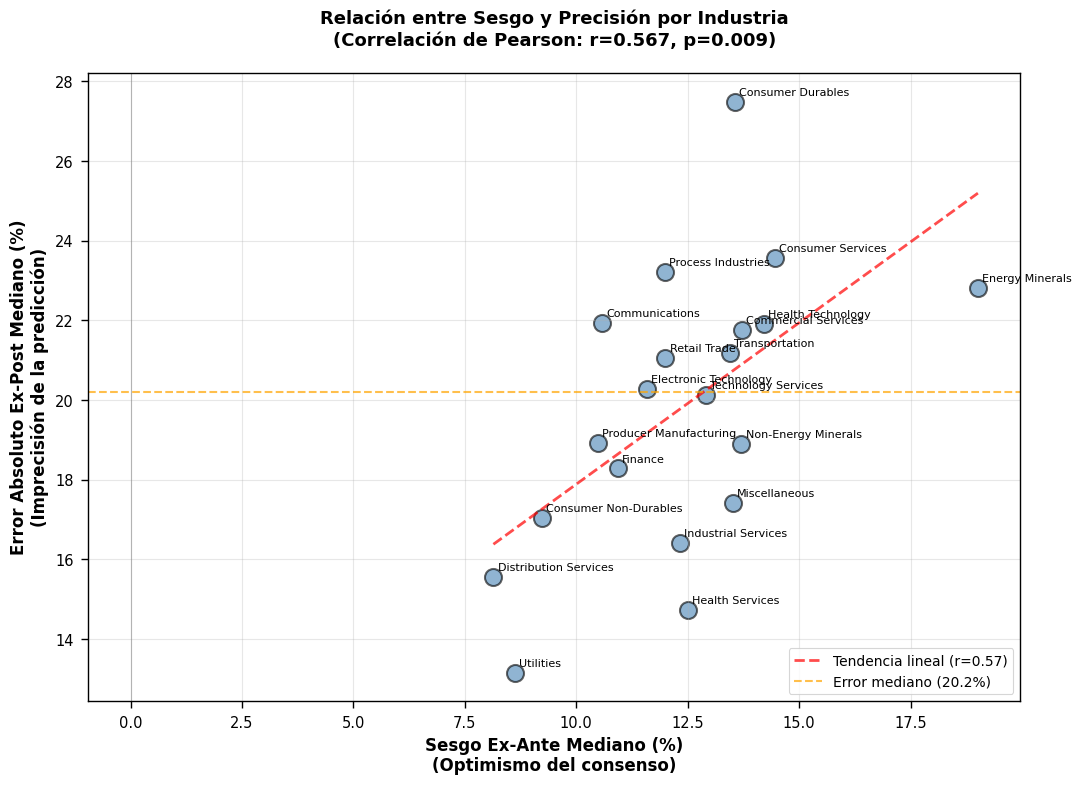


✅ Scatter plot guardado
   - N industrias: 20

⚠️ INDUSTRIAS CON 'DOBLE PROBLEMA' (alto sesgo + alto error):
----------------------------------------------------------------------
   Consumer Services              | Sesgo:  14.4% | Error:  23.6%
   Energy Minerals                | Sesgo:  19.0% | Error:  22.8%


In [ ]:
# ============================================================================
# 4.6. RELACIÓN SESGO EX-ANTE vs ERROR EX-POST
# ============================================================================

print("\n" + "="*70)
print("SCATTER PLOT: SESGO EX-ANTE vs ERROR EX-POST")
print("="*70)

# Agregar por industria
agg_industria = df_monthly.groupby('industria_nombre').agg({
    'bias_0': 'median',
    'error_abs_12m': 'median'
}).reset_index()

# Eliminar missing
agg_industria = agg_industria.dropna()

# Correlación
corr_pearson, pval_pearson = pearsonr(agg_industria['bias_0'], agg_industria['error_abs_12m'])
corr_spearman, pval_spearman = spearmanr(agg_industria['bias_0'], agg_industria['error_abs_12m'])

print(f"📊 CORRELACIÓN SESGO vs ERROR:")
print(f"   → Pearson: r = {corr_pearson:.3f} (p = {pval_pearson:.3f})")
print(f"   → Spearman: ρ = {corr_spearman:.3f} (p = {pval_spearman:.3f})")

if abs(corr_pearson) < 0.3:
    interpretacion = "Correlación DÉBIL → Sesgo y error son dimensiones independientes"
elif abs(corr_pearson) < 0.6:
    interpretacion = "Correlación MODERADA → Cierta relación entre sesgo y error"
else:
    interpretacion = "Correlación FUERTE → Industrias optimistas tienden a ser imprecisas"

print(f"   → Interpretación: {interpretacion}")

# Crear scatter plot
fig, ax = plt.subplots(figsize=(11, 8))

# Scatter
scatter = ax.scatter(agg_industria['bias_0'] * 100,
                     agg_industria['error_abs_12m'] * 100,
                     s=150, alpha=0.6, c='steelblue', edgecolors='black', linewidth=1.5)

# Etiquetas de industrias
for idx, row in agg_industria.iterrows():
    ax.annotate(row['industria_nombre'],
                (row['bias_0'] * 100, row['error_abs_12m'] * 100),
                fontsize=8, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

# Línea de tendencia (regresión lineal)
slope, intercept, r_value, p_value, std_err = linregress(
    agg_industria['bias_0'],
    agg_industria['error_abs_12m']
)

# Calculate R-squared here
r_squared = r_value**2
print(f"   → R-cuadrado de la regresión lineal: {r_squared:.3f}")

x_line = np.array([agg_industria['bias_0'].min(), agg_industria['bias_0'].max()])
y_line = (slope * x_line + intercept) * 100
x_line = x_line * 100

ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.7,
        label=f'Tendencia lineal (r={corr_pearson:.2f})')

# Líneas de referencia
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.axhline(y=agg_industria['error_abs_12m'].median() * 100,
           color='orange', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f"Error mediano ({agg_industria['error_abs_12m'].median()*100:.1f}%)")

# Configuración
ax.set_xlabel('Sesgo Ex-Ante Mediano (%)\n(Optimismo del consenso)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('Error Absoluto Ex-Post Mediano (%)\n(Imprecisión de la predicción)',
              fontsize=12, fontweight='bold')
ax.set_title(f'Relación entre Sesgo y Precisión por Industria\n(Correlación de Pearson: r={corr_pearson:.3f}, p={pval_pearson:.3f})',
             fontsize=13, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(fig, 'Fig11_scatter_sesgo_vs_error')
plt.show()

print(f"\n✅ Scatter plot guardado")
print(f"   - N industrias: {len(agg_industria)}")

# Identificar industrias "doble problema" (alto sesgo + alto error)
umbral_sesgo = agg_industria['bias_0'].quantile(0.75)
umbral_error = agg_industria['error_abs_12m'].quantile(0.75)

doble_problema = agg_industria[
    (agg_industria['bias_0'] > umbral_sesgo) &
    (agg_industria['error_abs_12m'] > umbral_error)
]

if len(doble_problema) > 0:
    print(f"\n⚠️ INDUSTRIAS CON 'DOBLE PROBLEMA' (alto sesgo + alto error):")
    print("-"*70)
    for idx, row in doble_problema.iterrows():
        print(f"   {row['industria_nombre']:30} | Sesgo: {row['bias_0']*100:5.1f}% | Error: {row['error_abs_12m']*100:5.1f}%")
else:
    print(f"\n✅ No hay industrias con 'doble problema' claro")

## 4.7. Sesgo optimista generalizado: test de signo por industria

El análisis anterior (sección 4.6) documenta que sesgo ex-ante y error ex-post
correlacionan positivamente a nivel sectorial. Sin embargo, un hallazgo previo
merece tratamiento propio: ¿es el sesgo optimista un fenómeno generalizado
en todas las industrias, o está concentrado en un subconjunto?

**Procedimiento:**
1. Tabla de sesgo mediano (`bias_0`) por industria
2. Test de Wilcoxon signed-rank a nivel global (H₀: mediana del sesgo = 0)
3. Test de Wilcoxon signed-rank por industria (20 tests individuales)

Se utiliza Wilcoxon en lugar de un test t por ser no paramétrico y robusto
a la asimetría de la distribución de sesgo.

In [ ]:
# ============================================================================
# 4.7. SESGO OPTIMISTA GENERALIZADO: TEST DE SIGNO POR INDUSTRIA
# ============================================================================

print("="*70)
print("SESGO OPTIMISTA GENERALIZADO: TEST DE SIGNO")
print("="*70)

# --- Datos válidos de sesgo ---
df_sesgo = df_monthly.dropna(subset=['bias_0']).copy()
print(f"\n📊 N observaciones con bias_0: {len(df_sesgo):,}")
print(f"   N industrias: {df_sesgo['industria_nombre'].nunique()}")

# ============================================================================
# PASO 1: TEST GLOBAL — ¿Es el sesgo significativamente positivo?
# ============================================================================

print(f"\n{'='*70}")
print("PASO 1: TEST GLOBAL DE WILCOXON")
print("="*70)

sesgo_global = df_sesgo['bias_0'].values
mediana_global = np.median(sesgo_global)
media_global = np.mean(sesgo_global)
pct_positivo_global = (sesgo_global > 0).mean() * 100

# Wilcoxon signed-rank test: H0: mediana = 0, H1: mediana > 0
stat_global, p_global_two = wilcoxon(sesgo_global, alternative='two-sided')
_, p_global_one = wilcoxon(sesgo_global, alternative='greater')

print(f"\n   Mediana global del sesgo: {mediana_global:.4f} ({mediana_global*100:.2f}%)")
print(f"   Media global del sesgo:   {media_global:.4f}")
print(f"   % observaciones con sesgo > 0: {pct_positivo_global:.1f}%")
print(f"\n   Test de Wilcoxon (H₀: mediana = 0):")
print(f"      Estadístico W: {stat_global:,.0f}")
print(f"      p-value (bilateral): {formatear_pvalor(p_global_two)}")
print(f"      p-value (unilateral, H₁: mediana > 0): {formatear_pvalor(p_global_one)}")

if p_global_one < 0.001:
    print(f"\n   ✅ El sesgo es significativamente POSITIVO a nivel global (p < 0.001)")
elif p_global_one < 0.05:
    print(f"\n   ✅ El sesgo es significativamente POSITIVO a nivel global (p < 0.05)")
else:
    print(f"\n   ⚠️  El sesgo NO es significativamente positivo a nivel global")

# ============================================================================
# PASO 2: TEST POR INDUSTRIA
# ============================================================================

print(f"\n{'='*70}")
print("PASO 2: TEST DE WILCOXON POR INDUSTRIA")
print("="*70)

resultados_signo = []

for industria in sorted(df_sesgo['industria_nombre'].unique()):
    datos = df_sesgo[df_sesgo['industria_nombre'] == industria]['bias_0'].values

    mediana = np.median(datos)
    pct_pos = (datos > 0).mean() * 100
    n_obs = len(datos)

    # Wilcoxon signed-rank test unilateral (H1: mediana > 0)
    try:
        stat_w, p_one = wilcoxon(datos, alternative='greater')
        _, p_two = wilcoxon(datos, alternative='two-sided')
    except ValueError:
        # Si todos los valores son iguales, wilcoxon falla
        stat_w, p_one, p_two = np.nan, np.nan, np.nan

    resultados_signo.append({
        'Industria': industria,
        'N obs': n_obs,
        'Sesgo mediano': mediana,
        'Sesgo mediano (%)': mediana * 100,
        '% positivo': pct_pos,
        'W statistic': stat_w,
        'p (unilateral)': p_one,
        'p (bilateral)': p_two,
        'Sig. (>0)': '***' if p_one < 0.001 else '**' if p_one < 0.01 else '*' if p_one < 0.05 else 'n.s.'
    })

df_signo = pd.DataFrame(resultados_signo).sort_values('Sesgo mediano', ascending=False)

# Tabla formateada para pantalla
print(f"\n{'Industria':<28} {'N':>6} {'Sesgo med.':>10} {'% pos.':>7} {'p (>0)':>12} {'Sig.':>5}")
print("-"*75)
for _, row in df_signo.iterrows():
    p_str = formatear_pvalor(row['p (unilateral)']) if not pd.isna(row['p (unilateral)']) else 'N/A'
    print(f"{row['Industria']:<28} {row['N obs']:>6,} {row['Sesgo mediano (%)']:>9.2f}% {row['% positivo']:>6.1f}% {p_str:>12} {row['Sig. (>0)']:>5}")

# Resumen
n_sig_pos = sum(1 for r in resultados_signo if r['p (unilateral)'] < 0.05)
n_total = len(resultados_signo)
n_mediana_pos = sum(1 for r in resultados_signo if r['Sesgo mediano'] > 0)

print(f"\n{'='*70}")
print("SÍNTESIS")
print("="*70)
print(f"\n   Industrias con sesgo mediano > 0:                    {n_mediana_pos}/{n_total}")
print(f"   Industrias con sesgo significativamente > 0 (p<0.05): {n_sig_pos}/{n_total}")
print(f"   Sesgo mediano global:                                 {mediana_global*100:.2f}%")

if n_sig_pos == n_total:
    print(f"\n   ✅ El sesgo optimista es UNIVERSAL: significativamente positivo en TODAS las industrias")
elif n_sig_pos >= n_total * 0.8:
    print(f"\n   ✅ El sesgo optimista es GENERALIZADO: significativamente positivo en {n_sig_pos} de {n_total} industrias")
elif n_sig_pos >= n_total * 0.5:
    print(f"\n   ⚠️  El sesgo optimista es PARCIAL: significativamente positivo en {n_sig_pos} de {n_total} industrias")
else:
    print(f"\n   ❌ El sesgo optimista es LIMITADO: significativamente positivo solo en {n_sig_pos} de {n_total} industrias")

# Guardar tabla
guardar_tabla(df_signo, 'Tabla_Sesgo_Optimista_Test_Signo')

print(f"\n✅ Análisis de sesgo optimista generalizado completado")

SESGO OPTIMISTA GENERALIZADO: TEST DE SIGNO

📊 N observaciones con bias_0: 34,596
   N industrias: 20

PASO 1: TEST GLOBAL DE WILCOXON

   Mediana global del sesgo: 0.1175 (11.75%)
   Media global del sesgo:   0.3129
   % observaciones con sesgo > 0: 88.8%

   Test de Wilcoxon (H₀: mediana = 0):
      Estadístico W: 31,574,644
      p-value (bilateral): < 0.001***
      p-value (unilateral, H₁: mediana > 0): < 0.001***

   ✅ El sesgo es significativamente POSITIVO a nivel global (p < 0.001)

PASO 2: TEST DE WILCOXON POR INDUSTRIA

Industria                         N Sesgo med.  % pos.       p (>0)  Sig.
---------------------------------------------------------------------------
Energy Minerals               1,064     19.01%   98.8%   < 0.001***   ***
Consumer Services             1,878     14.45%   89.9%   < 0.001***   ***
Health Technology             3,027     14.22%   92.6%   < 0.001***   ***
Commercial Services             906     13.71%   87.7%   < 0.001***   ***
Non-Energy Minera

---
# 5️⃣ PERSISTENCIA TEMPORAL

Análisis de estabilidad de rankings industriales en el tiempo.

## 5.1. Correlación Spearman (1ª vs 2ª mitad)

In [ ]:
# Dividir muestra temporalmente
meses_unicos = sorted(df_monthly['month'].unique())
mid = len(meses_unicos) // 2
primera_mitad = set(meses_unicos[:mid])
segunda_mitad = set(meses_unicos[mid:])

# Rankings por período
def ranking_periodo(df, meses, horizonte=12):
  df_periodo = df[df['month'].isin(meses)]
  return (df_periodo.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[f'error_abs_{horizonte}m'].median())

rank1 = ranking_periodo(df_monthly, primera_mitad).rank(ascending=False)
rank2 = ranking_periodo(df_monthly, segunda_mitad).rank(ascending=False)

# Spearman
industrias_comunes = rank1.index.intersection(rank2.index)
rho, pval = spearmanr(rank1.loc[industrias_comunes], rank2.loc[industrias_comunes])
print(f"PERSISTENCIA TEMPORAL (Spearman)")
print("="*50)
print(f"ρ (1ª vs 2ª mitad): {rho:.3f}")
print(f"p-value: {formatear_pvalor(pval)}")
print(f"\nInterpretación: {'Alta' if rho > 0.7 else 'Moderada' if rho > 0.4 else 'Baja'} persistencia")
print("\n✅ Análisis de persistencia completado")

PERSISTENCIA TEMPORAL (Spearman)
ρ (1ª vs 2ª mitad): 0.215
p-value: 0.363

Interpretación: Baja persistencia

✅ Análisis de persistencia completado


## 5.2. Rolling window analysis
**ESPECIFICACIONES:**
- Ventanas de 12 meses
- Calcular ρ entre mes t y mes t+12
- Gráfico de evolución temporal de ρ
- Identificar períodos de ruptura


ROLLING WINDOW ANALYSIS - Persistencia temporal dinámica

📊 ESTADÍSTICOS DE PERSISTENCIA ROLLING
N ventanas analizadas: 49
ρ promedio: 0.364
ρ mediano: 0.405
ρ mínimo: -0.146
ρ máximo: 0.765
Desv. estándar: 0.238

Ventanas con ρ significativo (p<0.05): 15 de 49 (30.6%)

⚠️ PERÍODOS DE BAJA PERSISTENCIA (ρ < 0.2):
----------------------------------------------------------------------
2021-11 → 2022-11: ρ = 0.150
2021-12 → 2022-12: ρ = 0.081
2022-01 → 2023-01: ρ = -0.146
2022-02 → 2023-02: ρ = -0.096
2022-03 → 2023-03: ρ = -0.042
2022-04 → 2023-04: ρ = 0.161
2022-05 → 2023-05: ρ = 0.089
2022-06 → 2023-06: ρ = -0.008
2022-10 → 2023-10: ρ = 0.200
2022-11 → 2023-11: ρ = 0.189
2023-02 → 2024-02: ρ = 0.197
📋 Tabla guardada: resultados_tfg/tablas/Tabla_Rolling_Window_Persistencia.xlsx
📊 Figura guardada: resultados_tfg/figuras/Fig06_rolling_window_persistencia.png


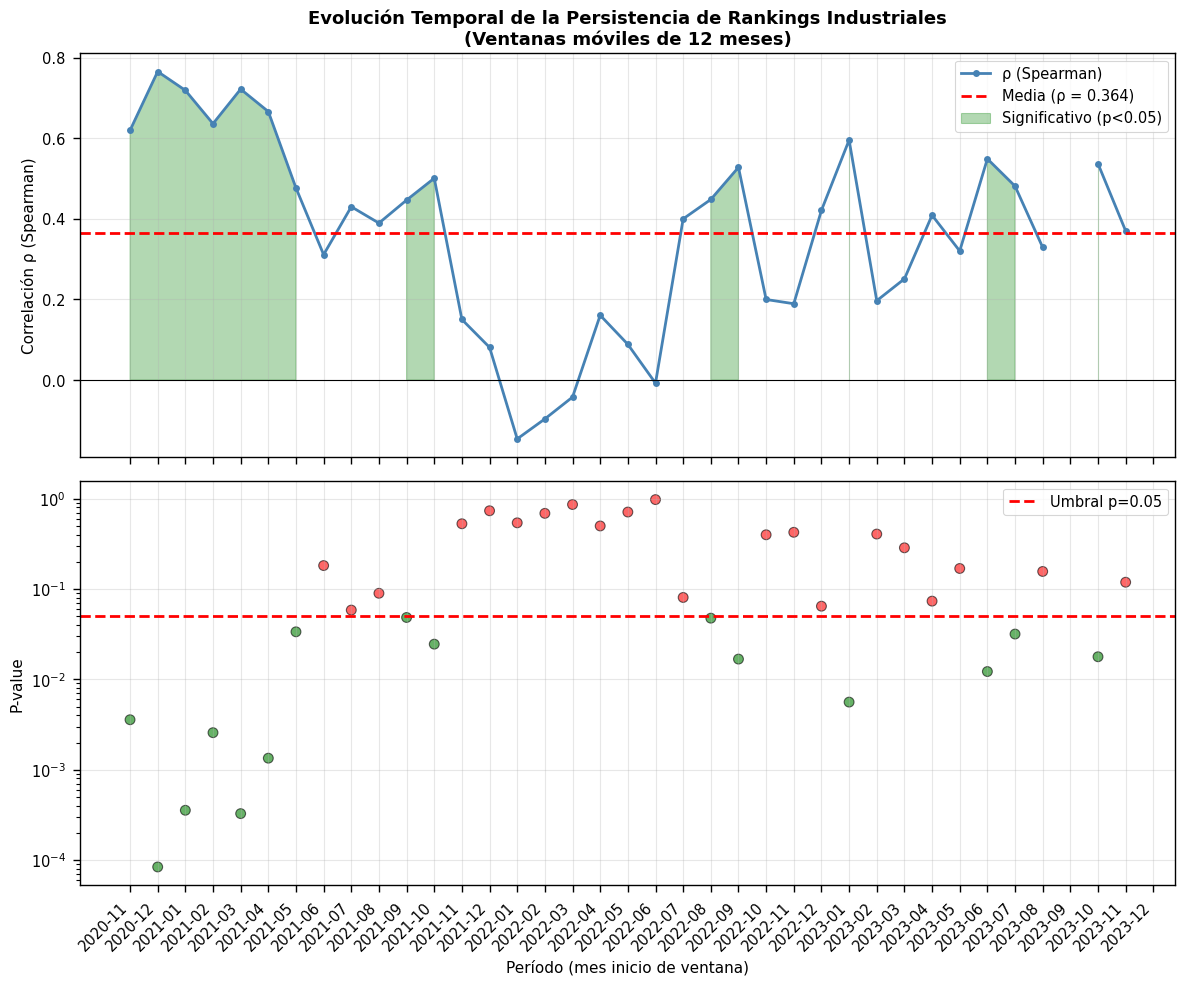


✅ Rolling window analysis completado


In [ ]:
# ============================================================================
# 5.2. ROLLING WINDOW ANALYSIS - Persistencia dinámica
# ============================================================================

print("\n" + "="*70)
print("ROLLING WINDOW ANALYSIS - Persistencia temporal dinámica")
print("="*70)

# Parámetros
ventana = 12  # meses
horizonte = 12  # meses para error

# Obtener meses únicos ordenados
meses_unicos = sorted(df_monthly['month'].unique())

# Calcular ρ en ventanas móviles
resultados_rolling = []

for i in range(len(meses_unicos) - ventana):
    # Ventana actual
    mes_inicio = meses_unicos[i]
    mes_fin = meses_unicos[i + ventana - 1]

    # Ventana siguiente (12 meses después del inicio)
    if i + ventana < len(meses_unicos):
        mes_comparacion = meses_unicos[i + ventana]
    else:
        break

    # Datos de ventana actual
    df_ventana1 = df_monthly[
        (df_monthly['month'] >= mes_inicio) &
        (df_monthly['month'] <= mes_fin)
    ]

    # Datos de mes de comparación
    df_ventana2 = df_monthly[df_monthly['month'] == mes_comparacion]

    # Rankings
    rank1 = df_ventana1.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[f'error_abs_{horizonte}m'].median()
    rank2 = df_ventana2.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[f'error_abs_{horizonte}m'].median()

    # Industrias comunes
    industrias_comunes = rank1.index.intersection(rank2.index)

    if len(industrias_comunes) >= 10:  # Mínimo 10 industrias para calcular
        rho, pval = spearmanr(
            rank1.loc[industrias_comunes].rank(ascending=False),
            rank2.loc[industrias_comunes].rank(ascending=False)
        )

        resultados_rolling.append({
            'mes_inicio': mes_inicio,
            'mes_fin': mes_fin,
            'mes_comparacion': mes_comparacion,
            'rho': rho,
            'pval': pval,
            'n_industrias': len(industrias_comunes)
        })

# Convertir a DataFrame
df_rolling = pd.DataFrame(resultados_rolling)

# Estadísticos del rolling window
print(f"\n📊 ESTADÍSTICOS DE PERSISTENCIA ROLLING")
print("="*70)
print(f"N ventanas analizadas: {len(df_rolling)}")
print(f"ρ promedio: {df_rolling['rho'].mean():.3f}")
print(f"ρ mediano: {df_rolling['rho'].median():.3f}")
print(f"ρ mínimo: {df_rolling['rho'].min():.3f}")
print(f"ρ máximo: {df_rolling['rho'].max():.3f}")
print(f"Desv. estándar: {df_rolling['rho'].std():.3f}")
print(f"\nVentanas con ρ significativo (p<0.05): {(df_rolling['pval'] < 0.05).sum()} de {len(df_rolling)} ({(df_rolling['pval'] < 0.05).mean()*100:.1f}%)")

# Identificar períodos de baja persistencia
print(f"\n⚠️ PERÍODOS DE BAJA PERSISTENCIA (ρ < 0.2):")
print("-"*70)
df_baja = df_rolling[df_rolling['rho'] < 0.2].copy()
if len(df_baja) > 0:
    df_baja['año_inicio'] = df_baja['mes_inicio'].dt.year
    for idx, row in df_baja.iterrows():
        print(f"{row['mes_inicio'].strftime('%Y-%m')} → {row['mes_comparacion'].strftime('%Y-%m')}: ρ = {row['rho']:.3f}")
else:
    print("No hay períodos con ρ < 0.2")

# Guardar tabla
guardar_tabla(df_rolling, 'Tabla_Rolling_Window_Persistencia')

# VISUALIZACIÓN: Evolución de ρ en el tiempo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Panel superior: Evolución de ρ
ax1.plot(df_rolling['mes_inicio'].astype(str), df_rolling['rho'],
         marker='o', linewidth=2, markersize=5, color='steelblue', label='ρ (Spearman)')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.axhline(y=df_rolling['rho'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Media (ρ = {df_rolling["rho"].mean():.3f})')
ax1.fill_between(range(len(df_rolling)), 0, df_rolling['rho'],
                  where=(df_rolling['pval'] < 0.05), alpha=0.3,
                  color='green', label='Significativo (p<0.05)')
ax1.set_ylabel('Correlación ρ (Spearman)', fontsize=11)
ax1.set_title('Evolución Temporal de la Persistencia de Rankings Industriales\n(Ventanas móviles de 12 meses)',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Panel inferior: P-values
ax2.scatter(df_rolling['mes_inicio'].astype(str), df_rolling['pval'],
            c=['green' if p < 0.05 else 'red' for p in df_rolling['pval']],
            s=50, alpha=0.6, edgecolors='black')
ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Umbral p=0.05')
ax2.set_xlabel('Período (mes inicio de ventana)', fontsize=11)
ax2.set_ylabel('P-value', fontsize=11)
ax2.set_yscale('log')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Rotar etiquetas eje x
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Ajustar layout para que las etiquetas no se corten
plt.tight_layout()

# Guardar
guardar_figura(fig, 'Fig06_rolling_window_persistencia')
plt.show()

print("\n✅ Rolling window analysis completado")

## 5.3. Clasificación de industrias: Clustering Jerárquico Aglomerativo

**OBJETIVO:** Clasificar las 19 industrias según su patrón temporal de
volatilidad de rankings, utilizando clustering jerárquico aglomerativo
con linkage Ward como alternativa metodológicamente robusta a la
clasificación por terciles.

**PROCEDIMIENTO:**
- Paso 1: Construcción de la matriz de rankings mensuales (19 × 49)
- Paso 2: Estandarización con StandardScaler
- Paso 3: Reducción de dimensionalidad con PCA
- Paso 4: Selección de hiperparámetros con Pipeline + GridSearch
- Paso 5: Ajuste del modelo final
- Paso 6: Dendrograma
- Paso 7: Interpretación y etiquetado de clusters
- Paso 8: Validación estadística con Kruskal-Wallis
- Paso 9: Comparación con clasificación original

In [ ]:
# ============================================================================
# 5.3. CLUSTERING JERÁRQUICO: SWITCHERS VS STABLE
# PASO 1: Construcción de la matriz de rankings mensuales
# ============================================================================
# Para cada mes con datos válidos, se calcula el ranking relativo de cada
# industria según su error absoluto mediano (rank 1 = peor precisión,
# rank 19 = mejor precisión). La matriz resultante (19 industrias × 49 meses)
# constituye la representación más completa del patrón temporal de cada sector.
#
# DECISIONES METODOLÓGICAS:
# 1. Horizonte de 12 meses como referencia (estándar en literatura y en el
#    resto del análisis). Los últimos 12 meses del panel (dic 2024 - nov 2025)
#    no tienen precio futuro disponible por construcción de la variable
#    ex-post, por lo que se trabaja con los 49 meses con datos completos
#    (nov 2020 - nov 2024), consistente con la regresión de efectos fijos.
# 2. Miscellaneous excluida: única empresa en la categoría (error mediano
#    no representativo de sector) y categoría sin coherencia conceptual
#    como industria homogénea.
# ============================================================================

print("\n" + "="*70)
print("PASO 1: CONSTRUCCIÓN DE LA MATRIZ DE RANKINGS MENSUALES")
print("="*70)

# --- 1.1. Excluir Miscellaneous ---
industrias_excluidas = ['Miscellaneous']
df_clustering = df_monthly[
    ~df_monthly['industria_nombre'].isin(industrias_excluidas)
].copy()

print(f"\n📋 INDUSTRIAS EXCLUIDAS: {industrias_excluidas}")
print(f"   Industrias restantes: {df_clustering['industria_nombre'].nunique()}")

# --- 1.2. Filtrar meses con datos válidos de error_abs_12m ---
# Los últimos 12 meses no tienen precio futuro disponible por construcción
# de la variable ex-post (shift -12 fuera del panel)
meses_validos = (
    df_clustering
    .dropna(subset=['error_abs_12m'])
    ['month']
    .unique()
)
meses_validos = sorted(meses_validos)

df_clustering = df_clustering[
    df_clustering['month'].isin(meses_validos)
].copy()

print(f"\n📅 COBERTURA TEMPORAL:")
print(f"   - Meses válidos (con error_abs_12m): {len(meses_validos)}")
print(f"   - Período: {str(meses_validos[0])} → {str(meses_validos[-1])}")
print(f"   - Meses excluidos (sin precio futuro): "
      f"{61 - len(meses_validos)} (dic 2024 - nov 2025)")

# --- 1.3. Error mediano por industria y mes ---
error_mensual = (
    df_clustering
    .groupby(['industria_nombre', 'month'])['error_abs_12m']
    .median()
    .reset_index()
    .rename(columns={'error_abs_12m': 'error_mediano'})
)

# --- 1.4. Ranking por mes (dentro de los 49 meses válidos) ---
# Rank 1 = industria con PEOR precisión ese mes
# Rank 19 = industria con MEJOR precisión ese mes
error_mensual['rank_mensual'] = (
    error_mensual
    .groupby('month')['error_mediano']
    .rank(ascending=False, method='average')
)

# --- 1.5. Pivotamos: filas = industrias, columnas = meses ---
matriz_rankings = error_mensual.pivot(
    index='industria_nombre',
    columns='month',
    values='rank_mensual'
)

# --- 1.6. Diagnóstico de missing residual ---
n_missing = matriz_rankings.isnull().sum().sum()
pct_missing = n_missing / matriz_rankings.size * 100

print(f"\n📊 DIMENSIONES DE LA MATRIZ FINAL:")
print(f"   - Industrias: {matriz_rankings.shape[0]}")
print(f"   - Meses: {matriz_rankings.shape[1]}")
print(f"   - Missing residual: {n_missing} ({pct_missing:.1f}%)")

if n_missing > 0:
    print(f"\n⚠️  MISSING POR INDUSTRIA (solo las afectadas):")
    missing_ind = matriz_rankings.isnull().sum(axis=1)
    print(missing_ind[missing_ind > 0].to_string())
    print(f"\n   → Imputación: mediana de la propia industria a lo largo")
    print(f"     del tiempo (conserva el nivel típico de ranking)")
    matriz_rankings = matriz_rankings.apply(
        lambda row: row.fillna(row.median()), axis=1
    )
    print(f"   → Missing tras imputación: "
          f"{matriz_rankings.isnull().sum().sum()}")
else:
    print(f"\n✅ Sin missing residual. No se requiere imputación.")

print(f"\n📋 MUESTRA DE LA MATRIZ (5 industrias × 5 meses):")
print(matriz_rankings.iloc[:5, :5].round(1).to_string())

print(f"\n✅ Paso 1 completado. Matriz lista para estandarización.")


PASO 1: CONSTRUCCIÓN DE LA MATRIZ DE RANKINGS MENSUALES

📋 INDUSTRIAS EXCLUIDAS: ['Miscellaneous']
   Industrias restantes: 19

📅 COBERTURA TEMPORAL:
   - Meses válidos (con error_abs_12m): 49
   - Período: 2020-11 → 2024-11
   - Meses excluidos (sin precio futuro): 12 (dic 2024 - nov 2025)

📊 DIMENSIONES DE LA MATRIZ FINAL:
   - Industrias: 19
   - Meses: 49
   - Missing residual: 0 (0.0%)

✅ Sin missing residual. No se requiere imputación.

📋 MUESTRA DE LA MATRIZ (5 industrias × 5 meses):
month                  2020-11  2020-12  2021-01  2021-02  2021-03
industria_nombre                                                  
Commercial Services     2.0000   2.0000   6.0000   2.0000   8.0000
Communications          6.0000   8.0000   8.0000  16.0000  12.0000
Consumer Durables      15.0000  17.0000  14.0000  13.0000   2.0000
Consumer Non-Durables  19.0000  18.0000  17.0000  17.0000  14.0000
Consumer Services      14.0000  16.0000  12.0000   5.0000   6.0000

✅ Paso 1 completado. Matriz lista

### Paso 2: Estandarización con StandardScaler

Se aplica StandardScaler sobre la matriz de rankings (19 × 49) para
centrar cada mes (columna) a media 0 y desviación estándar 1.

Aplicamos StandardScaler como paso estándar previo a PCA. En este caso los datos ya son rankings con escala homogénea, por lo que el impacto de la estandarización es mínimo, pero se mantiene por consistencia metodológica con el pipeline estándar de sklearn.

In [ ]:
# ============================================================================
# PASO 2: ESTANDARIZACIÓN CON STANDARDSCALER
# ============================================================================
# StandardScaler centra cada variable (mes) a media 0 y desviación 1.
# Aunque los rankings comparten escala por construcción (1-19), la
# estandarización es necesaria antes de PCA para que ningún mes domine
# las componentes principales por tener mayor dispersión de rankings.
# Se ajusta sobre la matriz completa (fit_transform), ya que no existe
# separación train/test en clustering no supervisado.
# ============================================================================

print("\n" + "="*70)
print("PASO 2: ESTANDARIZACIÓN CON STANDARDSCALER")
print("="*70)

# --- 2.1. Ajuste y transformación ---
scaler = StandardScaler()
matriz_scaled = scaler.fit_transform(matriz_rankings)

# Convertir a DataFrame manteniendo índice y columnas
matriz_scaled_df = pd.DataFrame(
    matriz_scaled,
    index=matriz_rankings.index,
    columns=matriz_rankings.columns
)

# --- 2.2. Verificación ---
medias = matriz_scaled_df.mean(axis=0)
desviaciones = matriz_scaled_df.std(axis=0)

print(f"\n📊 VERIFICACIÓN POST-ESTANDARIZACIÓN:")
print(f"   - Media por mes    → min: {medias.min():.6f} | "
      f"max: {medias.max():.6f} | esperado: ~0")
print(f"   - Desv. std por mes → min: {desviaciones.min():.6f} | "
      f"max: {desviaciones.max():.6f} | esperado: ~1")

# --- 2.3. Comparación antes/después para una industria ---
print(f"\n📋 EJEMPLO: Communications (antes vs después):")
print(f"   Antes → media: {matriz_rankings.loc['Communications'].mean():.2f} | "
      f"std: {matriz_rankings.loc['Communications'].std():.2f}")
print(f"   Después → media: {matriz_scaled_df.loc['Communications'].mean():.4f} | "
      f"std: {matriz_scaled_df.loc['Communications'].std():.4f}")

print(f"\n✅ Paso 2 completado. Matriz estandarizada lista para PCA.")


PASO 2: ESTANDARIZACIÓN CON STANDARDSCALER

📊 VERIFICACIÓN POST-ESTANDARIZACIÓN:
   - Media por mes    → min: -0.000000 | max: 0.000000 | esperado: ~0
   - Desv. std por mes → min: 1.027402 | max: 1.027402 | esperado: ~1

📋 EJEMPLO: Communications (antes vs después):
   Antes → media: 8.88 | std: 5.84
   Después → media: -0.2049 | std: 1.0663

✅ Paso 2 completado. Matriz estandarizada lista para PCA.


### Paso 3: Reducción de dimensionalidad con PCA

Se aplica PCA sobre la matriz estandarizada para reducir la
dimensionalidad de 49 meses a un número reducido de componentes
principales, eliminando la multicolinealidad entre meses adyacentes
(los rankings de períodos consecutivos están correlacionados).

El número óptimo de componentes se determina empíricamente mediante
el criterio de varianza explicada acumulada. PCA se incluye como paso
opcional en el pipeline del Paso 4: el GridSearch evaluará también
la opción de no aplicar PCA ('passthrough'), dejando que los datos
determinen si la reducción de dimensionalidad mejora la calidad
del clustering.


PASO 3: ANÁLISIS PCA - VARIANZA EXPLICADA

📊 VARIANZA EXPLICADA POR COMPONENTE:
 Componente  Varianza (%)  Acumulada (%)
----------------------------------------
          1         28.2%          28.2%
          2         17.2%          45.4%
          3         10.5%          55.9%
          4         10.0%          65.8%
          5          8.4%          74.3%
          6          5.6%          79.9%
          7          4.1%          84.0% ◄
          8          3.1%          87.1%
          9          2.7%          89.8%
         10          2.3%          92.1%

   → Componentes para explicar 70% varianza: 5

   → Componentes para explicar 80% varianza: 7

   → Componentes para explicar 90% varianza: 10
📊 Figura guardada: resultados_tfg/figuras/Fig_PCA_varianza_explicada.png

📋 INTERPRETACIÓN DE LAS PRIMERAS 2 COMPONENTES:

   PC1 — correlación con ranking medio: 0.983
   PC1 — correlación con volatilidad:   -0.069
   PC2 — correlación con ranking medio: 0.128
   PC2 — correlaci

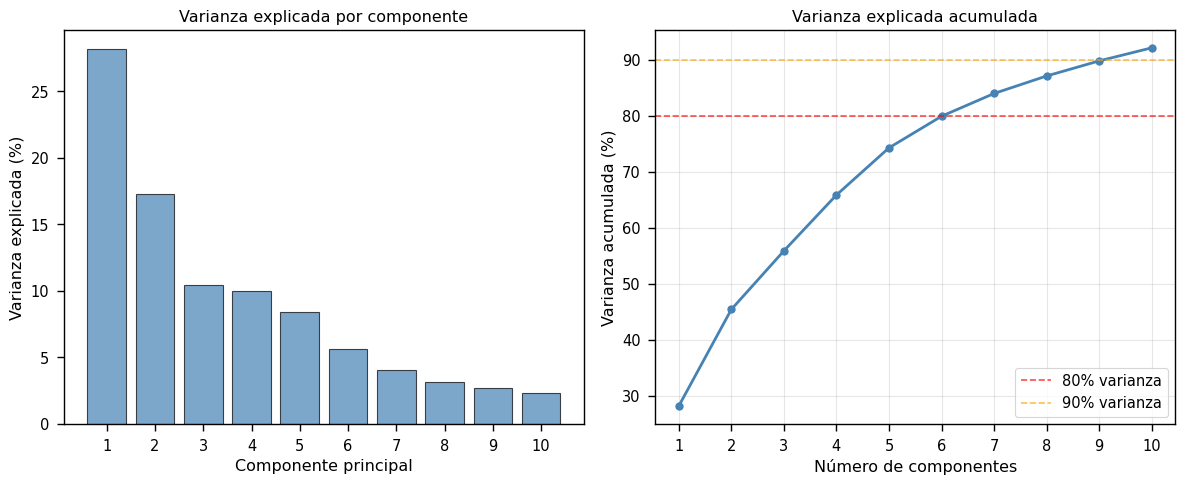

In [ ]:
# ============================================================================
# PASO 3: ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
# ============================================================================
# PCA reduce la dimensionalidad de 49 meses a componentes ortogonales que
# capturan la mayor parte de la varianza. Esto elimina la multicolinealidad
# entre meses adyacentes (rankings consecutivos están correlacionados) y
# reduce el ruido antes del clustering.
#
# Con N=19 industrias y p=49 variables, el número máximo de componentes
# informativos es min(N-1, p) = 18. Aquí exploramos cuántos componentes
# son necesarios para explicar el 80-90% de la varianza, lo que guiará
# el rango de búsqueda en el GridSearch del Paso 4.
#
# NOTA: PCA es un paso opcional en el pipeline. El GridSearch del Paso 4
# evaluará también 'passthrough' (sin PCA), dejando que los datos
# determinen si la reducción de dimensionalidad mejora el clustering.
# ============================================================================

print("\n" + "="*70)
print("PASO 3: ANÁLISIS PCA - VARIANZA EXPLICADA")
print("="*70)

# --- 3.1. PCA completo para explorar varianza explicada ---
pca_full = PCA(random_state=SEED)
pca_full.fit(matriz_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# --- 3.2. Tabla de varianza por componente ---
print(f"\n📊 VARIANZA EXPLICADA POR COMPONENTE:")
print(f"{'Componente':>11} {'Varianza (%)':>13} {'Acumulada (%)':>14}")
print("-"*40)
for i, (var, acum) in enumerate(
    zip(varianza_explicada[:10], varianza_acumulada[:10]), 1
):
    marker = " ◄" if acum >= 0.80 and varianza_acumulada[i-2] < 0.80 else ""
    marker = " ◄" if i == 1 and acum >= 0.80 else marker
    print(f"{i:>11} {var*100:>12.1f}% {acum*100:>13.1f}%{marker}")

# Umbrales clave
for umbral in [0.70, 0.80, 0.90]:
    n_comp = np.argmax(varianza_acumulada >= umbral) + 1
    print(f"\n   → Componentes para explicar {umbral*100:.0f}% varianza: {n_comp}")

# --- 3.3. Visualización: Scree plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: varianza por componente
axes[0].bar(range(1, 11), varianza_explicada[:10] * 100,
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xticks(range(1, 11))

# Panel derecho: varianza acumulada
axes[1].plot(range(1, 11), varianza_acumulada[:10] * 100,
             'o-', color='steelblue', linewidth=2, markersize=6)
axes[1].axhline(y=80, color='red', linestyle='--',
                alpha=0.7, label='80% varianza')
axes[1].axhline(y=90, color='orange', linestyle='--',
                alpha=0.7, label='90% varianza')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza explicada acumulada')
axes[1].set_xticks(range(1, 11))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(fig, 'Fig_PCA_varianza_explicada')

# --- 3.4. Interpretación de las primeras componentes ---
print(f"\n📋 INTERPRETACIÓN DE LAS PRIMERAS 2 COMPONENTES:")
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=matriz_rankings.columns,
    columns=['PC1', 'PC2']
)

# Correlación de cada componente con el ranking medio y la volatilidad
ranking_medio = matriz_rankings.mean(axis=1)
ranking_std = matriz_rankings.std(axis=1)

scores = pca_full.transform(matriz_scaled)[:, :2]
scores_df = pd.DataFrame(scores,
                          index=matriz_rankings.index,
                          columns=['PC1', 'PC2'])

corr_pc1_media = scores_df['PC1'].corr(ranking_medio)
corr_pc1_std = scores_df['PC1'].corr(ranking_std)
corr_pc2_media = scores_df['PC2'].corr(ranking_medio)
corr_pc2_std = scores_df['PC2'].corr(ranking_std)

print(f"\n   PC1 — correlación con ranking medio: {corr_pc1_media:.3f}")
print(f"   PC1 — correlación con volatilidad:   {corr_pc1_std:.3f}")
print(f"   PC2 — correlación con ranking medio: {corr_pc2_media:.3f}")
print(f"   PC2 — correlación con volatilidad:   {corr_pc2_std:.3f}")
print(f"\n   → PC1 captura principalmente: "
      f"{'nivel medio de error' if abs(corr_pc1_media) > abs(corr_pc1_std) else 'volatilidad de rankings'}")
print(f"   → PC2 captura principalmente: "
      f"{'nivel medio de error' if abs(corr_pc2_media) > abs(corr_pc2_std) else 'volatilidad de rankings'}")

print(f"\n✅ Paso 3 completado. Rango de componentes para GridSearch definido.")

### Paso 4: Selección de hiperparámetros con Pipeline + GridSearch

Se construye un Pipeline de sklearn que encadena tres pasos:
estandarización (StandardScaler), reducción de dimensionalidad
opcional (PCA) y clustering jerárquico (AgglomerativeClustering,
linkage Ward).

Se realiza un GridSearch exhaustivo sobre el espacio de hiperparámetros:
- pca: [3, 4, 5, 6, 7, 8 componentes, passthrough (sin PCA)]
- n_clusters: [2, 3, 4, 5]

La selección del modelo óptimo se basa en dos métricas evaluadas
simultáneamente:
- Coeficiente de Silhouette (maximizar): mide cohesión interna
  y separación entre clusters.
- Índice de Calinski-Harabasz (maximizar): mide la ratio entre
  dispersión inter-cluster e intra-cluster.

La combinación óptima es aquella que maximiza ambas métricas de
forma consistente. En caso de discrepancia, el Silhouette tiene
prioridad por ser la métrica estándar en clustering no supervisado.

Linkage Ward seleccionado por ser el más apropiado para datos
continuos con clusters compactos: minimiza la varianza intra-cluster
en cada fusión, produciendo grupos equilibrados e interpretables.
Single linkage descartado por efecto cadena; complete y average
inferiores a Ward para esta estructura de datos.

In [ ]:
# ============================================================================
# PASO 4: PIPELINE + GRIDSEARCH
# ============================================================================
# Pipeline: StandardScaler → PCA (opcional) → AgglomerativeClustering(Ward)
#
# NOTA TÉCNICA: sklearn no soporta GridSearchCV directamente con clustering
# no supervisado (no hay y_true para scoring). Se implementa un GridSearch
# manual iterando sobre el espacio de hiperparámetros y evaluando con
# silhouette_score (métrica principal) y calinski_harabasz_score (secundaria).
#
# Criterio de selección: silhouette_score como métrica principal por ser
# el estándar en clustering no supervisado — mide cohesión interna y
# separación entre clusters sin depender de la escala de los datos.
# Calinski-Harabasz se reporta como confirmación: si ambas métricas
# coinciden en el óptimo, la configuración queda doblemente validada.
#
# 'passthrough' en PCA equivale a no aplicar reducción de dimensionalidad,
# permitiendo que el GridSearch determine empíricamente si PCA mejora
# la calidad del clustering.
# ============================================================================

print("\n" + "="*70)
print("PASO 4: PIPELINE + GRIDSEARCH")
print("="*70)

# --- 4.1. Espacio de hiperparámetros ---
param_grid = {
    'n_components': [3, 4, 5, 6, 7, 8, 'passthrough'],
    'n_clusters':   [2, 3, 4, 5]
}

print(f"\n📋 ESPACIO DE BÚSQUEDA:")
print(f"   - PCA n_components: {param_grid['n_components']}")
print(f"   - n_clusters:       {param_grid['n_clusters']}")
print(f"   - Combinaciones totales: "
      f"{len(param_grid['n_components']) * len(param_grid['n_clusters'])}")

# --- 4.2. GridSearch manual ---
resultados_grid = []

for n_comp, n_clust in itertools.product(
    param_grid['n_components'], param_grid['n_clusters']
):
    # --- Transformación previa al clustering ---
    # Paso 1: estandarizar siempre
    scaler = StandardScaler()
    X_transformado = scaler.fit_transform(matriz_rankings)

    # Paso 2: PCA opcional
    pca_obj = None
    if n_comp != 'passthrough':
        pca_obj = PCA(n_components=n_comp, random_state=SEED)
        X_transformado = pca_obj.fit_transform(X_transformado)

    # Paso 3: clustering
    clustering = AgglomerativeClustering(
        n_clusters=n_clust,
        linkage='ward'
    )
    labels = clustering.fit_predict(X_transformado)

    # --- Métricas ---
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X_transformado, labels)
        cal = calinski_harabasz_score(X_transformado, labels)
    else:
        sil, cal = np.nan, np.nan

    resultados_grid.append({
        'n_components': n_comp,
        'n_clusters':   n_clust,
        'silhouette':   sil,
        'calinski':     cal,
        'X_transformado': X_transformado,  # guardamos para uso posterior
        'labels':       labels
    })

# --- 4.3. Ordenar por silhouette (criterio principal) ---
# Desempate por Calinski-Harabasz si silhouettes son iguales
df_grid = pd.DataFrame([{k: v for k, v in r.items()
                          if k not in ('labels', 'X_transformado')}
                         for r in resultados_grid])

df_grid_sorted = df_grid.sort_values(
    ['silhouette', 'calinski'],
    ascending=[False, False]
).reset_index()  # reset_index guarda el índice original en columna 'index'

print(f"\n📊 TOP 10 COMBINACIONES (ordenadas por Silhouette):")
print(f"\n{'n_comp':>8} {'n_clust':>8} {'Silhouette':>11} {'Calinski':>10}")
print("-"*42)
for _, row in df_grid_sorted.head(10).iterrows():
    print(f"{str(row['n_components']):>8} {int(row['n_clusters']):>8} "
          f"{row['silhouette']:>11.4f} {row['calinski']:>10.2f}")

# --- 4.4. Configuración óptima ---
# Usamos el índice original guardado en 'index' tras reset_index
mejor_original_idx = df_grid_sorted.iloc[0]['index']
mejor = df_grid_sorted.iloc[0]
mejor_labels      = resultados_grid[mejor_original_idx]['labels']
mejor_X           = resultados_grid[mejor_original_idx]['X_transformado']

print(f"\n🏆 CONFIGURACIÓN ÓPTIMA:")
print(f"   - PCA n_components: {mejor['n_components']}")
print(f"   - n_clusters:       {int(mejor['n_clusters'])}")
print(f"   - Silhouette:       {mejor['silhouette']:.4f}")
print(f"   - Calinski-Harabasz:{mejor['calinski']:.2f}")

# Verificar convergencia entre métricas
mejor_calinski_idx = df_grid.sort_values(
    'calinski', ascending=False
).index[0]
mejor_calinski = df_grid.iloc[mejor_calinski_idx]

print(f"\n📋 VERIFICACIÓN DE CONVERGENCIA ENTRE MÉTRICAS:")
print(f"   Óptimo por Silhouette → "
      f"n_comp={mejor['n_components']}, "
      f"n_clusters={int(mejor['n_clusters'])}")
print(f"   Óptimo por Calinski   → "
      f"n_comp={mejor_calinski['n_components']}, "
      f"n_clusters={int(mejor_calinski['n_clusters'])}")

if (mejor['n_components'] == mejor_calinski['n_components'] and
        int(mejor['n_clusters']) == int(mejor_calinski['n_clusters'])):
    print(f"   ✅ CONVERGENCIA: ambas métricas apuntan a la misma configuración")
else:
    print(f"   ⚠️  DIVERGENCIA: métricas apuntan a configuraciones distintas")
    print(f"   → Se selecciona el óptimo por Silhouette (criterio principal)")

# Guardar para pasos siguientes
opt_n_components = mejor['n_components']
opt_n_clusters   = int(mejor['n_clusters'])
opt_labels       = mejor_labels
opt_X            = mejor_X

print(f"\n✅ Paso 4 completado. Configuración óptima identificada.")


PASO 4: PIPELINE + GRIDSEARCH

📋 ESPACIO DE BÚSQUEDA:
   - PCA n_components: [3, 4, 5, 6, 7, 8, 'passthrough']
   - n_clusters:       [2, 3, 4, 5]
   - Combinaciones totales: 28

📊 TOP 10 COMBINACIONES (ordenadas por Silhouette):

  n_comp  n_clust  Silhouette   Calinski
------------------------------------------
       3        4      0.3227      10.36
       3        5      0.3199      10.27
       3        2      0.2953       9.25
       3        3      0.2888      10.47
       4        2      0.2620       8.50
       4        5      0.2399       6.75
       4        4      0.2248       6.78
       5        2      0.2185       7.08
       4        3      0.2109       7.45
       5        3      0.1914       6.09

🏆 CONFIGURACIÓN ÓPTIMA:
   - PCA n_components: 3
   - n_clusters:       4
   - Silhouette:       0.3227
   - Calinski-Harabasz:10.36

📋 VERIFICACIÓN DE CONVERGENCIA ENTRE MÉTRICAS:
   Óptimo por Silhouette → n_comp=3, n_clusters=4
   Óptimo por Calinski   → n_comp=3, n_clu

### Paso 5: Ajuste del modelo final

Se ajusta el modelo con la configuración óptima identificada en el
Paso 4 (PCA 3 componentes + Ward linkage). Dado que el GridSearch
reveló divergencia entre métricas (Silhouette → 4 clusters,
Calinski → 3 clusters), se ajustan ambas soluciones para que el
dendrograma del Paso 6 actúe como tercer criterio independiente
de decisión.

In [ ]:
# ============================================================================
# PASO 5: AJUSTE DEL MODELO FINAL
# ============================================================================
# Se ajusta el modelo con la configuración óptima del GridSearch:
# StandardScaler → PCA(3 componentes) → AgglomerativeClustering(Ward).
#
# Dado que Silhouette y Calinski divergen (4 vs 3 clusters), se ajustan
# ambas soluciones. El dendrograma del Paso 6 actuará como tercer criterio
# para la decisión final.
#
# AgglomerativeClustering es determinista con linkage Ward: dado el mismo
# input, produce siempre el mismo resultado. No requiere random_state.
# ============================================================================

print("\n" + "="*70)
print("PASO 5: AJUSTE DEL MODELO FINAL")
print("="*70)

# --- 5.1. Transformación común (StandardScaler + PCA 3 componentes) ---
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(matriz_rankings)

pca_final = PCA(n_components=3, random_state=SEED)
X_pca_final = pca_final.fit_transform(X_scaled_final)

varianza_retenida = pca_final.explained_variance_ratio_.sum()
print(f"\n📊 TRANSFORMACIÓN:")
print(f"   - StandardScaler aplicado sobre matriz 19×49")
print(f"   - PCA: 49 → 3 componentes")
print(f"   - Varianza retenida: {varianza_retenida*100:.1f}%")

# --- 5.2. Solución A: 4 clusters (óptimo por Silhouette) ---
clustering_4 = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_4 = clustering_4.fit_predict(X_pca_final)

sil_4 = silhouette_score(X_pca_final, labels_4)
cal_4 = calinski_harabasz_score(X_pca_final, labels_4)

# --- 5.3. Solución B: 3 clusters (óptimo por Calinski) ---
clustering_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_3 = clustering_3.fit_predict(X_pca_final)

sil_3 = silhouette_score(X_pca_final, labels_3)
cal_3 = calinski_harabasz_score(X_pca_final, labels_3)

# --- 5.4. Resumen comparativo ---
print(f"\n📊 COMPARACIÓN DE SOLUCIONES:")
print(f"\n{'':>30} {'4 clusters':>12} {'3 clusters':>12}")
print("-"*55)
print(f"{'Silhouette':>30} {sil_4:>12.4f} {sil_3:>12.4f}")
print(f"{'Calinski-Harabasz':>30} {cal_4:>12.2f} {cal_3:>12.2f}")
print(f"\n   → Silhouette favorece: "
      f"{'4 clusters' if sil_4 > sil_3 else '3 clusters'} "
      f"(Δ = {abs(sil_4-sil_3):.4f})")
print(f"   → Calinski favorece:   "
      f"{'4 clusters' if cal_4 > cal_3 else '3 clusters'} "
      f"(Δ = {abs(cal_4-cal_3):.2f})")

# --- 5.5. Composición de cada solución ---
for n_clust, labels in [(4, labels_4), (3, labels_3)]:
    print(f"\n📋 COMPOSICIÓN - {n_clust} CLUSTERS:")
    print(f"{'Cluster':>8} {'N industrias':>14} {'Industrias'}")
    print("-"*70)
    for cluster_id in sorted(np.unique(labels)):
        industrias_cluster = matriz_rankings.index[labels == cluster_id].tolist()
        print(f"{cluster_id:>8} {len(industrias_cluster):>14}   "
              f"{', '.join(industrias_cluster)}")

# --- 5.6. Guardar para pasos siguientes ---
# X_pca_final: datos transformados (19×3) para dendrograma y visualizaciones
# labels_4, labels_3: etiquetas de ambas soluciones
# La decisión final entre 3 y 4 clusters se toma en el Paso 6

print(f"\n✅ Paso 5 completado. Ambas soluciones listas para el dendrograma.")


PASO 5: AJUSTE DEL MODELO FINAL

📊 TRANSFORMACIÓN:
   - StandardScaler aplicado sobre matriz 19×49
   - PCA: 49 → 3 componentes
   - Varianza retenida: 55.9%

📊 COMPARACIÓN DE SOLUCIONES:

                                 4 clusters   3 clusters
-------------------------------------------------------
                    Silhouette       0.3227       0.2888
             Calinski-Harabasz        10.36        10.47

   → Silhouette favorece: 4 clusters (Δ = 0.0339)
   → Calinski favorece:   3 clusters (Δ = 0.10)

📋 COMPOSICIÓN - 4 CLUSTERS:
 Cluster   N industrias Industrias
----------------------------------------------------------------------
       0              6   Consumer Non-Durables, Distribution Services, Health Services, Industrial Services, Producer Manufacturing, Utilities
       1              4   Electronic Technology, Energy Minerals, Health Technology, Process Industries
       2              6   Commercial Services, Communications, Finance, Non-Energy Minerals, Retail T

### Paso 6: Dendrograma

Se visualiza el dendrograma completo del clustering jerárquico con
linkage Ward sobre los datos transformados (PCA 3 componentes).

El dendrograma permite tomar la decisión final entre 3 y 4 clusters
actuando como tercer criterio independiente: si el corte a 4 clusters
se produce a una altura significativamente inferior al corte a 3
clusters, la subdivisión adicional no está justificada. Si ambos
cortes ocurren a alturas similares, 4 clusters es la solución más
informativa.

La altura de cada fusión en el dendrograma representa la distancia
euclídea entre clusters en el espacio PCA — cuanto mayor la altura,
más distintos son los grupos que se fusionan.


PASO 6: DENDROGRAMA

📊 ALTURAS DE FUSIÓN (últimas 5, de abajo arriba):
  Fusión   Desde n clusters   Hasta n clusters     Altura      Salto
--------------------------------------------------------------------
      14                  6                  5     8.0245     0.3201
      15                  5                  4     8.6130     0.5885
      16                  4                  3    10.5877     1.9747
      17                  3                  2    14.9392     4.3515
      18                  2                  1    19.1439     4.2047

📏 ALTURAS DE CORTE:
   Corte en 4 clusters: 10.5877
   Corte en 3 clusters: 14.9392
   Corte en 2 clusters: 19.1439

   Salto 4→3 clusters: 4.3515
   Salto 3→2 clusters: 4.2047

   Ratio salto (3→2) / (4→3): 0.97
   → Saltos similares: ambas soluciones justificables
📊 Figura guardada: resultados_tfg/figuras/Fig_Dendrograma_Clustering.png

✅ Paso 6 completado. Decisión final: ver dendrograma.


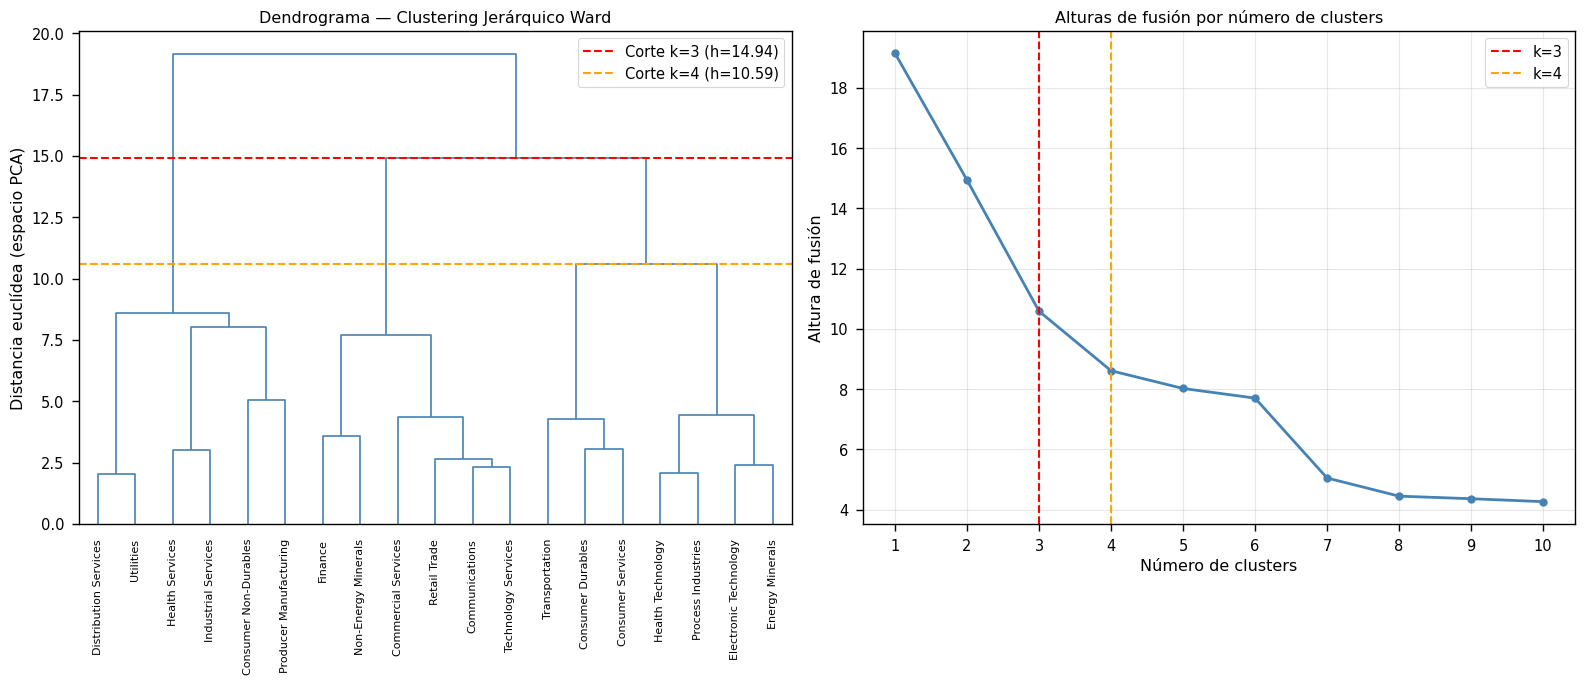

In [ ]:
# ============================================================================
# PASO 6: DENDROGRAMA
# ============================================================================
# El dendrograma visualiza el proceso completo de fusión jerárquica.
# Se construye directamente sobre X_pca_final (19 industrias × 3 componentes)
# usando scipy.cluster.hierarchy, que permite acceder a la matriz de linkage
# completa (necesaria para dibujar el dendrograma) — AgglomerativeClustering
# de sklearn no expone esta información.
#
# La decisión entre 3 y 4 clusters se toma observando las alturas de corte:
# - Si la última fusión (de 3 a 2 grupos) ocurre a una altura mucho mayor
#   que la penúltima (de 4 a 3 grupos), el salto indica que 3 clusters
#   es el corte natural.
# - Si las alturas son similares, 4 clusters es igualmente justificable.
# ============================================================================

print("\n" + "="*70)
print("PASO 6: DENDROGRAMA")
print("="*70)

# --- 6.1. Matriz de linkage Ward sobre X_pca_final ---
Z = linkage(X_pca_final, method='ward')

# --- 6.2. Alturas de fusión relevantes ---
# Z[:,2] contiene las distancias (alturas) de cada fusión
# Las últimas filas corresponden a las últimas fusiones (mayor distancia)
alturas = Z[:, 2]
n_fusiones = len(alturas)

print(f"\n📊 ALTURAS DE FUSIÓN (últimas 5, de abajo arriba):")
print(f"{'Fusión':>8} {'Desde n clusters':>18} {'Hasta n clusters':>18} "
      f"{'Altura':>10} {'Salto':>10}")
print("-"*68)
for i in range(4, -1, -1):
    idx = n_fusiones - 1 - i
    n_desde = i + 2
    n_hasta = i + 1
    altura = alturas[n_fusiones - 1 - i]
    salto = alturas[n_fusiones - 1 - i] - alturas[n_fusiones - 2 - i] \
        if idx > 0 else np.nan
    print(f"{idx+1:>8} {n_desde:>18} {n_hasta:>18} "
          f"{altura:>10.4f} {salto:>10.4f}")

# Altura al cortar en 3 y 4 clusters
altura_corte_4 = alturas[-3]  # corte que separa el 4º cluster
altura_corte_3 = alturas[-2]  # corte que separa el 3er cluster
altura_corte_2 = alturas[-1]  # corte que separa el 2º cluster

print(f"\n📏 ALTURAS DE CORTE:")
print(f"   Corte en 4 clusters: {altura_corte_4:.4f}")
print(f"   Corte en 3 clusters: {altura_corte_3:.4f}")
print(f"   Corte en 2 clusters: {altura_corte_2:.4f}")
print(f"\n   Salto 4→3 clusters: {altura_corte_3 - altura_corte_4:.4f}")
print(f"   Salto 3→2 clusters: {altura_corte_2 - altura_corte_3:.4f}")

ratio = (altura_corte_2 - altura_corte_3) / (altura_corte_3 - altura_corte_4)
print(f"\n   Ratio salto (3→2) / (4→3): {ratio:.2f}")
print(f"   → {'Salto pronunciado al pasar de 3 a 2: favorece k=3' if ratio > 1.5 else 'Saltos similares: ambas soluciones justificables'}")

# --- 6.3. Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: dendrograma con cortes en 3 y 4 clusters
ax1 = axes[0]
dend = dendrogram(
    Z,
    labels=list(matriz_rankings.index),
    orientation='top',
    ax=ax1,
    color_threshold=0,
    above_threshold_color='steelblue'
)
ax1.axhline(y=altura_corte_3 + 0.001, color='red', linestyle='--',
            linewidth=1.5, label=f'Corte k=3 (h={altura_corte_3:.2f})')
ax1.axhline(y=altura_corte_4 + 0.001, color='orange', linestyle='--',
            linewidth=1.5, label=f'Corte k=4 (h={altura_corte_4:.2f})')
ax1.set_title('Dendrograma — Clustering Jerárquico Ward')
ax1.set_ylabel('Distancia euclídea (espacio PCA)')
ax1.tick_params(axis='x', rotation=90, labelsize=8)
ax1.legend(loc='upper right')

# Panel derecho: gráfico de alturas de fusión (scree plot del dendrograma)
ax2 = axes[1]
last_n = 10
ultimas_alturas = alturas[-(last_n):]
x_vals = range(last_n, 0, -1)

ax2.plot(list(x_vals), ultimas_alturas, 'o-',
         color='steelblue', linewidth=2, markersize=6)
ax2.axvline(x=3, color='red', linestyle='--',
            linewidth=1.5, label='k=3')
ax2.axvline(x=4, color='orange', linestyle='--',
            linewidth=1.5, label='k=4')
ax2.set_xlabel('Número de clusters')
ax2.set_ylabel('Altura de fusión')
ax2.set_title('Alturas de fusión por número de clusters')
ax2.set_xticks(list(x_vals))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(fig, 'Fig_Dendrograma_Clustering')

print(f"\n✅ Paso 6 completado. Decisión final: ver dendrograma.")

### Paso 7: Interpretación y etiquetado de clusters

Una vez fijada la solución de k=4 clusters, se interpretan los grupos
resultantes analizando tres dimensiones para cada cluster:
1. Perfil de ranking temporal: evolución de rankings a lo largo de
   los 49 meses (¿estable o volátil?)
2. Nivel medio de error: ¿el cluster agrupa industrias precisas
   o imprecisas en términos absolutos?
3. Volatilidad de rankings: desviación estándar del ranking a lo
   largo del tiempo.

La combinación de estas tres dimensiones permite asignar etiquetas
interpretables a cada cluster y conectar el resultado con la
pregunta de investigación original.


PASO 7: INTERPRETACIÓN Y ETIQUETADO DE CLUSTERS

📊 ESTADÍSTICOS POR CLUSTER:

 Cluster    N  Rank medio  Std ranking    Rango Etiqueta
---------------------------------------------------------------------------
       0    6       12.82         4.77    16.83   Alta precisión
       1    4        7.99         4.40    16.00   Precisión media-baja
       2    6       10.08         5.06    17.33   Precisión media-alta
       3    3        6.87         4.97    16.33   Baja precisión

📋 COMPOSICIÓN DETALLADA POR CLUSTER:

  Cluster 0 — Alta precisión:
  Industria                     Rank medio      Std    Rango
  ----------------------------------------------------------
  Industrial Services                11.82     5.40    18.00
  Consumer Non-Durables              11.47     5.24    18.00
  Producer Manufacturing             10.86     4.92    16.00
  Health Services                    13.80     4.52    18.00
  Utilities                          15.47     4.40    17.00
  Distribution Servi

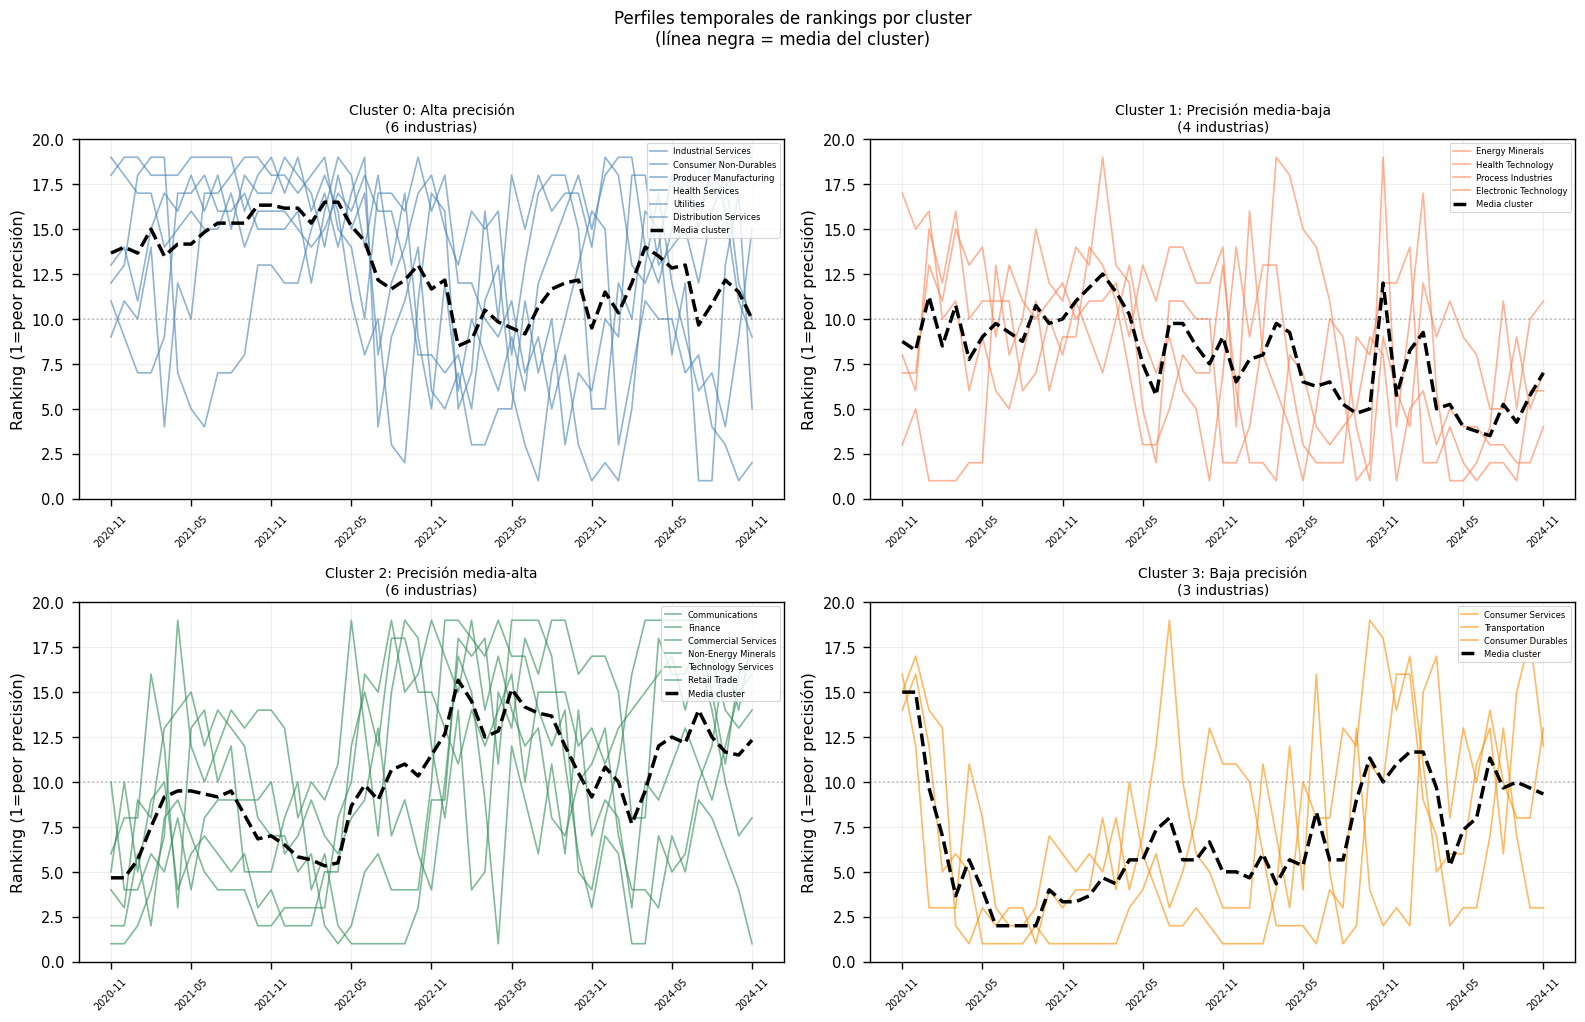

In [ ]:
# ============================================================================
# PASO 7: INTERPRETACIÓN Y ETIQUETADO DE CLUSTERS
# ============================================================================
# Se caracteriza cada cluster en tres dimensiones:
# 1. Volatilidad de rankings (std del ranking a lo largo del tiempo)
# 2. Nivel medio de error absoluto (posición media en ranking global)
# 3. Perfil temporal (evolución visual de rankings por cluster)
#
# El etiquetado se basa en estas dimensiones, no en una asignación
# arbitraria, garantizando que las etiquetas reflejan el patrón
# empírico observado.
# ============================================================================

print("\n" + "="*70)
print("PASO 7: INTERPRETACIÓN Y ETIQUETADO DE CLUSTERS")
print("="*70)

# --- 7.1. Añadir etiquetas de cluster a la matriz de rankings ---
df_clusters = pd.DataFrame({
    'industria':  matriz_rankings.index,
    'cluster':    labels_4,
    'rank_medio': matriz_rankings.mean(axis=1).values,
    'rank_std':   matriz_rankings.std(axis=1).values,
    'rank_min':   matriz_rankings.min(axis=1).values,
    'rank_max':   matriz_rankings.max(axis=1).values,
    'rango':      (matriz_rankings.max(axis=1) -
                   matriz_rankings.min(axis=1)).values
}).sort_values(['cluster', 'rank_std'], ascending=[True, False])

# --- 7.2. Estadísticos por cluster ---
print(f"\n📊 ESTADÍSTICOS POR CLUSTER:")
print(f"\n{'Cluster':>8} {'N':>4} {'Rank medio':>11} "
      f"{'Std ranking':>12} {'Rango':>8} {'Etiqueta'}")
print("-"*75)

resumen_clusters = df_clusters.groupby('cluster').agg(
    n=('industria', 'count'),
    rank_medio=('rank_medio', 'mean'),
    rank_std=('rank_std', 'mean'),
    rango=('rango', 'mean')
).round(2)

# Etiquetas basadas únicamente en nivel de precisión relativa
# (rank alto = mejor precisión, rank bajo = peor precisión)
etiquetas = {
    0: "Alta precisión",
    1: "Precisión media-baja",
    2: "Precisión media-alta",
    3: "Baja precisión"
}

for cluster_id, row in resumen_clusters.iterrows():
    print(f"{cluster_id:>8} {int(row['n']):>4} {row['rank_medio']:>11.2f} "
          f"{row['rank_std']:>12.2f} {row['rango']:>8.2f} "
          f"  {etiquetas[cluster_id]}")

# --- 7.3. Composición detallada por cluster ---
print(f"\n📋 COMPOSICIÓN DETALLADA POR CLUSTER:")
for cluster_id in sorted(df_clusters['cluster'].unique()):
    df_c = df_clusters[df_clusters['cluster'] == cluster_id]
    print(f"\n  Cluster {cluster_id} — {etiquetas[cluster_id]}:")
    print(f"  {'Industria':<28} {'Rank medio':>11} "
          f"{'Std':>8} {'Rango':>8}")
    print(f"  {'-'*58}")
    for _, row in df_c.iterrows():
        print(f"  {row['industria']:<28} {row['rank_medio']:>11.2f} "
              f"{row['rank_std']:>8.2f} {row['rango']:>8.2f}")

# --- 7.4. Visualización: perfiles temporales por cluster ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

meses_str = [str(m) for m in matriz_rankings.columns]
x_ticks_idx = list(range(0, len(meses_str), 6))
x_ticks_labels = [meses_str[i] for i in x_ticks_idx]

colores = ['steelblue', 'coral', 'seagreen', 'darkorange']

for cluster_id in sorted(df_clusters['cluster'].unique()):
    ax = axes[cluster_id]
    industrias_c = df_clusters[
        df_clusters['cluster'] == cluster_id
    ]['industria'].tolist()

    for ind in industrias_c:
        ax.plot(range(len(meses_str)),
                matriz_rankings.loc[ind].values,
                alpha=0.6, linewidth=1.2,
                color=colores[cluster_id],
                label=ind)

    # Media del cluster
    media_cluster = matriz_rankings.loc[industrias_c].mean(axis=0)
    ax.plot(range(len(meses_str)), media_cluster.values,
            color='black', linewidth=2.5, linestyle='--',
            label='Media cluster')

    ax.set_title(f'Cluster {cluster_id}: {etiquetas[cluster_id]}\n'
                 f'({len(industrias_c)} industrias)',
                 fontsize=10)
    ax.set_ylabel('Ranking (1=peor precisión)')
    ax.set_ylim(0, 20)
    ax.set_xticks(x_ticks_idx)
    ax.set_xticklabels(x_ticks_labels, rotation=45, fontsize=7)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=10, color='gray', linestyle=':', alpha=0.5)

plt.suptitle('Perfiles temporales de rankings por cluster\n'
             '(línea negra = media del cluster)',
             fontsize=12, y=1.02)
plt.tight_layout()
guardar_figura(fig, 'Fig_Clustering_Perfiles_Temporales')

# --- 7.5. Guardar etiquetas para pasos siguientes ---
df_clusters['etiqueta'] = df_clusters['cluster'].map(etiquetas)

print(f"\n✅ Paso 7 completado. Clusters interpretados y etiquetados.")

### Paso 8: Validación estadística con test de Kruskal-Wallis

Se valida estadísticamente que los clusters identificados son
distinguibles entre sí en tres dimensiones:

1. **Nivel de error** (rank_medio): se espera diferencia significativa
   — es la dimensión dominante de separación identificada en el Paso 7.
2. **Volatilidad de rankings** (rank_std): se espera ausencia de
   diferencia significativa — confirmaría que la volatilidad es
   homogénea entre clusters, respondiendo a la tercera pregunta
   de investigación.
3. **Sesgo ex-ante** (bias_0): análisis post-hoc que examina si los
   clusters diferenciados por nivel de error también difieren en
   el optimismo del consenso de analistas, conectando con el
   hallazgo de la sección 4.1.5.

Test de Kruskal-Wallis seleccionado por ser no paramétrico y robusto
a outliers, consistente con el resto del análisis del trabajo.
H₀ en cada caso: los clusters provienen de la misma distribución.

In [ ]:
# ============================================================================
# PASO 8: VALIDACIÓN ESTADÍSTICA CON TEST DE KRUSKAL-WALLIS
# ============================================================================
# Una vez identificados los clusters, se valida estadísticamente que los
# grupos son distinguibles entre sí en dimensiones relevantes.
#
# Se testean tres dimensiones:
# 1. Nivel de error (rank_medio): dimensión dominante del clustering.
#    H₁: los clusters difieren en su nivel medio de error relativo.
# 2. Volatilidad de rankings (rank_std): dimensión secundaria.
#    H₁: los clusters difieren en volatilidad de rankings.
#    Resultado esperado: no significativo → volatilidad homogénea.
# 3. Sesgo ex-ante (bias_0): análisis post-hoc.
#    H₁: los clusters difieren en optimismo del consenso.
#
# Test de Kruskal-Wallis: no paramétrico, robusto a outliers,
# consistente con el resto del análisis del trabajo.
#
# NOTA: las métricas rank_medio y rank_std son estadísticos agregados
# por industria (19 observaciones). Para el sesgo ex-ante se usa la
# distribución completa de observaciones empresa-mes dentro de cada
# cluster, lo que proporciona mayor potencia estadística.
# ============================================================================

print("\n" + "="*70)
print("PASO 8: VALIDACIÓN ESTADÍSTICA — TEST DE KRUSKAL-WALLIS")
print("="*70)

# --- 8.1. Preparación: métricas agregadas por industria ---
# df_clusters ya contiene rank_medio, rank_std y etiqueta por industria
# Añadimos el sesgo ex-ante mediano por industria
sesgo_por_industria = (
    df_monthly[df_monthly['industria_nombre'].isin(df_clusters['industria'])]
    .groupby('industria_nombre')['bias_0']
    .median()
    .reset_index()
    .rename(columns={'industria_nombre': 'industria',
                     'bias_0': 'sesgo_mediano'})
)

df_val = df_clusters.merge(sesgo_por_industria, on='industria', how='left')

print(f"\n📋 DATOS DE VALIDACIÓN POR CLUSTER:")
print(f"\n{'Cluster':<22} {'N':>3} {'Rank medio':>11} "
      f"{'Std ranking':>12} {'Sesgo mediano':>14}")
print("-"*65)
for cluster_id in sorted(df_val['cluster'].unique()):
    df_c = df_val[df_val['cluster'] == cluster_id]
    etiq = etiquetas[cluster_id]
    print(f"{etiq:<22} {len(df_c):>3} "
          f"{df_c['rank_medio'].mean():>11.2f} "
          f"{df_c['rank_std'].mean():>12.2f} "
          f"{df_c['sesgo_mediano'].mean():>14.4f}")

# --- 8.2. Test de Kruskal-Wallis por dimensión ---
print(f"\n{'='*70}")
print(f"RESULTADOS DEL TEST DE KRUSKAL-WALLIS")
print(f"{'='*70}")

dimensiones = {
    'Nivel de error (rank_medio)': 'rank_medio',
    'Volatilidad de rankings (rank_std)': 'rank_std',
    'Sesgo ex-ante (bias_0 mediano)': 'sesgo_mediano'
}

resultados_kw = {}
for nombre, variable in dimensiones.items():
    # Extraer grupos por cluster
    grupos = [
        df_val[df_val['cluster'] == c][variable].dropna().values
        for c in sorted(df_val['cluster'].unique())
    ]
    # Solo testar si todos los grupos tienen al menos 2 observaciones
    if all(len(g) >= 2 for g in grupos):
        stat, pval = kruskal(*grupos)
    else:
        stat, pval = np.nan, np.nan

    resultados_kw[nombre] = {'H': stat, 'p': pval}

    sig = "***" if pval < 0.001 else \
          "**"  if pval < 0.01  else \
          "*"   if pval < 0.05  else \
          "n.s."
    esperado = "(esperado: sig.)" if variable == 'rank_medio' else \
               "(esperado: n.s.)" if variable == 'rank_std' else \
               "(post-hoc)"

    print(f"\n📊 {nombre} {esperado}:")
    print(f"   H-statistic: {stat:.4f}")
    print(f"   p-value:     {pval:.4f} {sig}")
    if pval < 0.05:
        print(f"   → Se rechaza H₀: los clusters difieren "
              f"significativamente en esta dimensión")
    else:
        print(f"   → No se rechaza H₀: los clusters NO difieren "
              f"significativamente en esta dimensión")

# --- 8.3. Síntesis de resultados ---
print(f"\n{'='*70}")
print(f"SÍNTESIS")
print(f"{'='*70}")

p_error = resultados_kw['Nivel de error (rank_medio)']['p']
p_vol   = resultados_kw['Volatilidad de rankings (rank_std)']['p']
p_sesgo = resultados_kw['Sesgo ex-ante (bias_0 mediano)']['p']

print(f"\n✅ Nivel de error:    "
      f"{'SIGNIFICATIVO' if p_error < 0.05 else 'NO SIGNIFICATIVO'} "
      f"(p={p_error:.4f})")
print(f"{'✅' if p_vol >= 0.05 else '⚠️ '} Volatilidad:       "
      f"{'HOMOGÉNEA (no sig.)' if p_vol >= 0.05 else 'HETEROGÉNEA (sig.)'} "
      f"(p={p_vol:.4f})")
print(f"   Sesgo ex-ante:    "
      f"{'SIGNIFICATIVO' if p_sesgo < 0.05 else 'NO SIGNIFICATIVO'} "
      f"(p={p_sesgo:.4f})")

# --- 8.4. Interpretación integrada ---
print(f"\n📋 INTERPRETACIÓN:")
if p_error < 0.05 and p_vol >= 0.05:
    print(f"""
   Los clusters son estadísticamente distinguibles en nivel de error
   (p={p_error:.4f}) pero NO en volatilidad de rankings (p={p_vol:.4f}).
   Esto confirma dos hallazgos simultáneamente:
   - Los 4 grupos identificados por el clustering son estadísticamente
     válidos: difieren significativamente en su nivel de precisión.
   - La volatilidad de rankings es homogénea entre clusters, respondiendo
     a la tercera pregunta de investigación: no existen grupos discretos
     de industrias inherentemente más o menos volátiles.""")
elif p_error < 0.05 and p_vol < 0.05:
    print(f"""
   Los clusters difieren tanto en nivel de error (p={p_error:.4f})
   como en volatilidad (p={p_vol:.4f}). El clustering captura
   ambas dimensiones simultáneamente.""")
else:
    print(f"""
   ⚠️  Resultado inesperado. Revisar composición de clusters.""")

if p_sesgo < 0.05:
    print(f"""
   Adicionalmente, los clusters difieren en sesgo ex-ante (p={p_sesgo:.4f}),
   lo que conecta con el hallazgo de la sección 4.1.5: las industrias
   con mayor error también tienden a mostrar mayor optimismo en el
   consenso de analistas.""")
else:
    print(f"""
   El sesgo ex-ante no difiere significativamente entre clusters
   (p={p_sesgo:.4f}), sugiriendo que el optimismo del consenso es
   independiente del nivel de precisión sectorial.""")

print(f"\n✅ Paso 8 completado. Clusters validados estadísticamente.")


PASO 8: VALIDACIÓN ESTADÍSTICA — TEST DE KRUSKAL-WALLIS

📋 DATOS DE VALIDACIÓN POR CLUSTER:

Cluster                  N  Rank medio  Std ranking  Sesgo mediano
-----------------------------------------------------------------
Alta precisión           6       12.82         4.77         0.1022
Precisión media-baja     4        7.99         4.40         0.1420
Precisión media-alta     6       10.08         5.06         0.1231
Baja precisión           3        6.87         4.97         0.1382

RESULTADOS DEL TEST DE KRUSKAL-WALLIS

📊 Nivel de error (rank_medio) (esperado: sig.):
   H-statistic: 13.2632
   p-value:     0.0041 **
   → Se rechaza H₀: los clusters difieren significativamente en esta dimensión

📊 Volatilidad de rankings (rank_std) (esperado: n.s.):
   H-statistic: 2.7447
   p-value:     0.4327 n.s.
   → No se rechaza H₀: los clusters NO difieren significativamente en esta dimensión

📊 Sesgo ex-ante (bias_0 mediano) (post-hoc):
   H-statistic: 7.7974
   p-value:     0.0504 n.s.

In [ ]:
# ============================================================================
# TABLAS PARA SECCIÓN 4.3 DEL TRABAJO ESCRITO (NUMERACIÓN FINAL)
# ============================================================================
# Tabla 3: Top 5 combinaciones GridSearch
# Tabla 4: Composición clusters K=3 y K=4
# Tabla 5: Estadísticos por cluster
# Tabla 6: Resultados Kruskal-Wallis
# ============================================================================

def estilo_academico(ws, titulo, df, start_row=1):
    thin = Side(style='thin')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    header_fill = PatternFill(start_color='D9E1F2', end_color='D9E1F2',
                               fill_type='solid')
    ws.cell(row=start_row, column=1, value=titulo)
    ws.cell(row=start_row, column=1).font = Font(bold=True, size=11)
    ws.merge_cells(start_row=start_row, start_column=1,
                   end_row=start_row, end_column=len(df.columns))
    for col_idx, col_name in enumerate(df.columns, 1):
        cell = ws.cell(row=start_row+1, column=col_idx, value=col_name)
        cell.font = Font(bold=True, size=10)
        cell.fill = header_fill
        cell.border = border
        cell.alignment = Alignment(horizontal='center', wrap_text=True)
    for row_idx, row in enumerate(df.itertuples(index=False), start_row+2):
        for col_idx, value in enumerate(row, 1):
            cell = ws.cell(row=row_idx, column=col_idx, value=value)
            cell.border = border
            cell.alignment = Alignment(horizontal='center', wrap_text=True)
    for col_idx in range(1, len(df.columns)+1):
        ws.column_dimensions[get_column_letter(col_idx)].width = 25
    return start_row + len(df) + 3

# ============================================================================
# TABLA 3: Top 5 combinaciones GridSearch
# ============================================================================
top5 = df_grid_sorted.head(5)[['n_components', 'n_clusters',
                                 'silhouette', 'calinski']].copy()
top5.columns = ['PCA n_components', 'n_clusters',
                 'Silhouette', 'Calinski-Harabasz']
top5['Silhouette'] = top5['Silhouette'].round(4)
top5['Calinski-Harabasz'] = top5['Calinski-Harabasz'].round(2)
top5['PCA n_components'] = top5['PCA n_components'].astype(str)

# ============================================================================
# TABLA 4: Composición clusters K=3 y K=4
# ============================================================================

# Etiquetas K=4
etiquetas_k4 = etiquetas  # {0: 'Alta precisión', 1: 'Precisión media-baja', ...}

# Etiquetas K=3: el Cluster 0 fusiona los Clusters 0 y 3 de K=4
etiquetas_k3 = {
    0: 'Alta y baja precisión fusionadas',
    1: 'Alta precisión',
    2: 'Precisión media-alta'
}

comp_k4 = {}
for cluster_id in sorted(np.unique(labels_4)):
    inds = sorted(matriz_rankings.index[labels_4 == cluster_id].tolist())
    etiq = etiquetas_k4[cluster_id]
    comp_k4[cluster_id] = f"{etiq} ({len(inds)}): {', '.join(inds)}"

comp_k3 = {}
for cluster_id in sorted(np.unique(labels_3)):
    inds = sorted(matriz_rankings.index[labels_3 == cluster_id].tolist())
    etiq = etiquetas_k3[cluster_id]
    comp_k3[cluster_id] = f"{etiq} ({len(inds)}): {', '.join(inds)}"

tabla_comp = pd.DataFrame({
    'Cluster': [f'Cluster {i}' for i in range(4)],
    'K=4 (óptimo por Silhouette)': [
        comp_k4.get(i, '—') for i in range(4)
    ],
    'K=3 (óptimo por Calinski-Harabasz)': [
        comp_k3.get(i, '—') for i in range(4)
    ]
})

# ============================================================================
# TABLA 5: Estadísticos por cluster
# ============================================================================
tabla4 = df_clusters.groupby(['cluster', 'etiqueta']).agg(
    N=('industria', 'count'),
    Rank_medio=('rank_medio', 'mean'),
    Std_ranking=('rank_std', 'mean'),
    Rango=('rango', 'mean')
).round(2).reset_index()

tabla4 = tabla4.sort_values('Rank_medio', ascending=False)
tabla4['Industrias'] = tabla4['cluster'].apply(
    lambda c: ', '.join(sorted(
        df_clusters[df_clusters['cluster'] == c]['industria'].tolist()
    ))
)
tabla4 = tabla4[['etiqueta', 'N', 'Rank_medio', 'Std_ranking', 'Rango', 'Industrias']]
tabla4.columns = ['Etiqueta', 'N industrias', 'Rank medio',
                   'Std ranking', 'Rango medio', 'Industrias']

# ============================================================================
# TABLA 6: Resultados Kruskal-Wallis
# ============================================================================
dim_names = {
    'Nivel de error (rank_medio)':          'Nivel de error (rank medio)',
    'Volatilidad de rankings (rank_std)':   'Volatilidad de rankings (rank std)',
    'Sesgo ex-ante (bias_0 mediano)':       'Sesgo ex-ante (bias mediano)'
}
esperado = {
    'Nivel de error (rank_medio)':          'Significativo',
    'Volatilidad de rankings (rank_std)':   'No significativo',
    'Sesgo ex-ante (bias_0 mediano)':       'Post-hoc'
}

kw_data = []
for dim, vals in resultados_kw.items():
    sig = "**" if vals['p'] < 0.01 else \
          "*"  if vals['p'] < 0.05 else "n.s."
    resultado = "Se rechaza H₀" if vals['p'] < 0.05 else "No se rechaza H₀"
    kw_data.append({
        'Dimensión': dim_names.get(dim, dim),
        'H-statistic': round(vals['H'], 4),
        'p-valor': f"{vals['p']:.4f} {sig}",
        'Resultado': resultado,
        'Resultado esperado': esperado.get(dim, '—')
    })

tabla5_kw = pd.DataFrame(kw_data)

# ============================================================================
# EXPORTAR A EXCEL
# ============================================================================
wb = Workbook()

ws1 = wb.active
ws1.title = "Tabla 3 - GridSearch"
estilo_academico(ws1,
    "Tabla 3. Top 5 combinaciones del GridSearch ordenadas por silhouette",
    top5)

ws2 = wb.create_sheet("Tabla 4 - Composición clusters")
estilo_academico(ws2,
    "Tabla 4. Composición de clusters para K=4 y K=3",
    tabla_comp)

ws3 = wb.create_sheet("Tabla 5 - Estadísticos clusters")
estilo_academico(ws3,
    "Tabla 5. Estadísticos descriptivos por cluster",
    tabla4)

ws4 = wb.create_sheet("Tabla 6 - Kruskal-Wallis")
estilo_academico(ws4,
    "Tabla 6. Resultados del test de Kruskal-Wallis por dimensión",
    tabla5_kw)

filepath = 'resultados_tfg/tablas/Tablas_Seccion_4_3_Clustering.xlsx'
wb.save(filepath)

print("✅ Tablas generadas:")
print(f"   Tabla 3 — Top 5 GridSearch")
print(f"   Tabla 4 — Composición K=3 vs K=4")
print(f"   Tabla 5 — Estadísticos por cluster")
print(f"   Tabla 6 — Kruskal-Wallis")
print(f"\n📁 Exportado: {filepath}")

✅ Tablas generadas:
   Tabla 3 — Top 5 GridSearch
   Tabla 4 — Composición K=3 vs K=4
   Tabla 5 — Estadísticos por cluster
   Tabla 6 — Kruskal-Wallis

📁 Exportado: resultados_tfg/tablas/Tablas_Seccion_4_3_Clustering.xlsx


---
# 6️⃣ ANÁLISIS DE ROBUSTEZ

Verificación de que los resultados son robustos a diferentes especificaciones.

## 6.1. R1: Sensibilidad a horizontes temporales
Replicar análisis principal para h = 6, 18, 24 meses.


ROBUSTEZ 1: SENSIBILIDAD A HORIZONTES TEMPORALES

📊 RESULTADOS POR HORIZONTE TEMPORAL
 horizonte  n_obs  gap_pp  error_medio  kruskal_H  kruskal_p  spearman_rho  spearman_p
         6  31024 17.5987       0.1576   811.3591 < 0.001***        0.3083      0.1861
         9  29253 11.5179       0.1807   771.7696 < 0.001***        0.3609      0.1180
        12  27493 14.3320       0.1979   638.3043 < 0.001***        0.2150      0.3626
        15  25740 13.3908       0.2137   590.2849 < 0.001***        0.0977      0.6818
        18  23998 14.7835       0.2261   583.8415 < 0.001***       -0.0150      0.9498
        24  20538 16.2124       0.2505   506.2593 < 0.001***        0.1895      0.4237

🔍 INTERPRETACIÓN:
----------------------------------------------------------------------
Gap mínimo: 11.52pp (h=9m)
Gap máximo: 17.60pp (h=6m)
Tendencia: Aumenta con horizonte

Persistencia promedio: ρ = 0.193
Significancia Kruskal: 6/6 horizontes con p<0.05
📋 Tabla guardada: resultados_tfg/tablas/Tabl

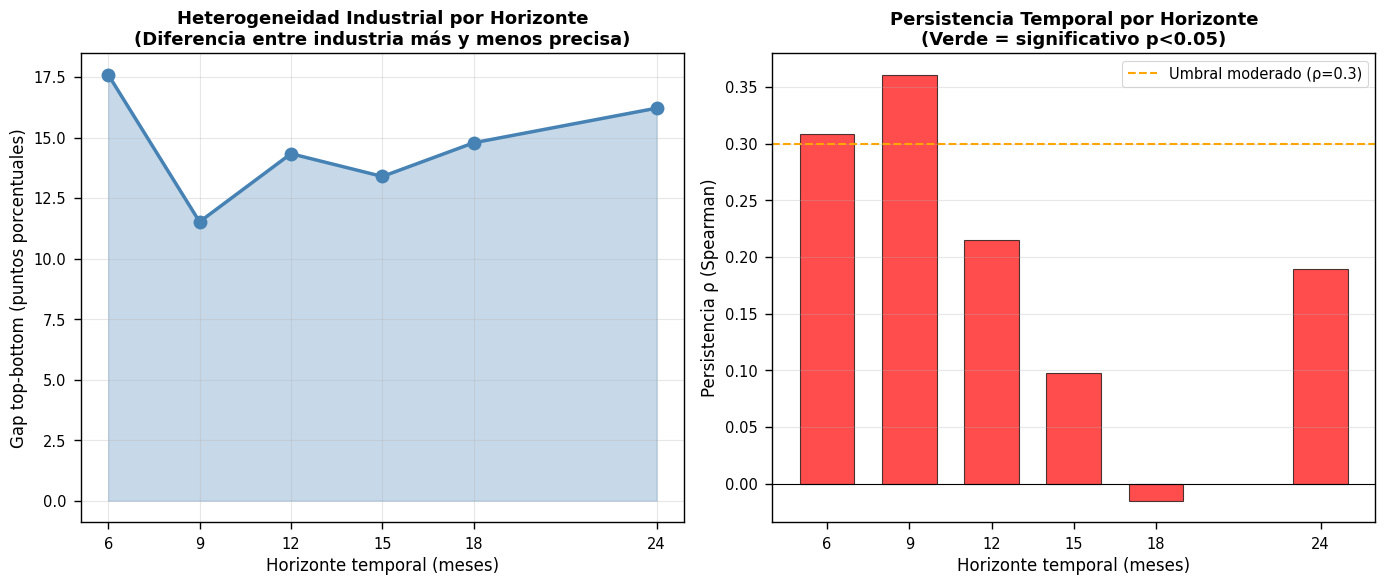


✅ Análisis de sensibilidad a horizontes completado


In [ ]:
# ============================================================================
# 6.1. R1: SENSIBILIDAD A HORIZONTES TEMPORALES
# ============================================================================

print("\n" + "="*70)
print("ROBUSTEZ 1: SENSIBILIDAD A HORIZONTES TEMPORALES")
print("="*70)

# Todos los horizontes a analizar
todos_horizontes = sorted(list(set(HORIZONTES_PRINCIPALES + HORIZONTES_ROBUSTEZ)))

# Resultados por horizonte
resultados_horizontes = []

for h in todos_horizontes:
    col_error = f'error_abs_{h}m'

    # Check if the column exists and has non-null values for robust calculations
    if col_error not in df_monthly.columns or df_monthly[col_error].isnull().all():
        print(f"⚠️ Columna {col_error} no existe o está vacía, saltando...")
        continue

    # Ranking por horizonte
    ranking_h = (
        df_monthly.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_error]
        .agg(['median', 'mean', 'count'])
        .sort_values('median', ascending=False)
        .reset_index()
    )

    # Ensure ranking is not empty before accessing iloc
    if ranking_h.empty:
        gap = np.nan
        error_medio = np.nan
    else:
        # Gap (top - bottom)
        gap = ranking_h['median'].iloc[0] - ranking_h['median'].iloc[-1]
        error_medio = ranking_h['median'].mean()

    # Kruskal-Wallis
    # Filter out industries with insufficient data (less than 2 unique values after dropna)
    grupos = [
        grupo[col_error].dropna().values
        for _, grupo in df_monthly.groupby('FREF_ENTITY_FACTSET_INDUSTRY')
    ]
    grupos = [g for g in grupos if len(np.unique(g)) > 1] # Kruskal needs at least 2 unique values per group

    if len(grupos) >= 2:
        stat_kw, pval_kw = kruskal(*grupos)
    else:
        stat_kw, pval_kw = np.nan, np.nan

    # Persistencia (1ª vs 2ª mitad)
    meses_unicos = sorted(df_monthly['month'].unique())
    mid = len(meses_unicos) // 2
    primera_mitad = set(meses_unicos[:mid])
    segunda_mitad = set(meses_unicos[mid:])

    rank1 = df_monthly[df_monthly['month'].isin(primera_mitad)].groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_error].median()
    rank2 = df_monthly[df_monthly['month'].isin(segunda_mitad)].groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_error].median()

    industrias_comunes = rank1.index.intersection(rank2.index)

    # Ensure enough common industries for Spearman correlation
    if len(industrias_comunes) >= 10:
        rho, pval_rho = spearmanr(
            rank1.loc[industrias_comunes].rank(ascending=False),
            rank2.loc[industrias_comunes].rank(ascending=False)
        )
    else:
        rho, pval_rho = np.nan, np.nan

    # N observaciones válidas
    n_obs = df_monthly[col_error].notna().sum()

    # Guardar resultados
    resultados_horizontes.append({
        'horizonte': h,
        'n_obs': n_obs,
        'gap_pp': gap * 100,  # En puntos porcentuales
        'error_medio': error_medio,
        'kruskal_H': stat_kw,
        'kruskal_p_raw': pval_kw,
        'kruskal_p': formatear_pvalor(pval_kw),
        'spearman_rho': rho,
        'spearman_p': pval_rho
    })

# Convertir a DataFrame
df_horizontes = pd.DataFrame(resultados_horizontes)

print("\n📊 RESULTADOS POR HORIZONTE TEMPORAL")
print("="*70)
print(df_horizontes[['horizonte', 'n_obs', 'gap_pp', 'error_medio', 'kruskal_H', 'kruskal_p', 'spearman_rho', 'spearman_p']].to_string(index=False))

# Interpretación
print("\n🔍 INTERPRETACIÓN:")
print("-"*70)
# Check if df_horizontes is empty before trying to access values
if not df_horizontes.empty:
    if not df_horizontes['gap_pp'].isnull().all():
        print(f"Gap mínimo: {df_horizontes['gap_pp'].min():.2f}pp (h={df_horizontes.loc[df_horizontes['gap_pp'].idxmin(), 'horizonte']:.0f}m)")
        print(f"Gap máximo: {df_horizontes['gap_pp'].max():.2f}pp (h={df_horizontes.loc[df_horizontes['gap_pp'].idxmax(), 'horizonte']:.0f}m)")
        if not df_horizontes['horizonte'].nunique() == 1 and not df_horizontes['gap_pp'].isnull().all():
            corr_gap_horizonte = df_horizontes['gap_pp'].corr(df_horizontes['horizonte'])
            if not pd.isna(corr_gap_horizonte):
                print(f"Tendencia: {'Aumenta con horizonte' if corr_gap_horizonte > 0 else 'Disminuye con horizonte'}")
            else:
                print("Tendencia: No se puede calcular (datos insuficientes)")
        else:
            print("Tendencia: No se puede calcular (solo un horizonte o datos faltantes)")
    else:
        print("Gap: No se pudo calcular para ningún horizonte.")

    if not df_horizontes['spearman_rho'].isnull().all():
        print(f"\nPersistencia promedio: ρ = {df_horizontes['spearman_rho'].mean():.3f}")
    else:
        print("\nPersistencia: No se pudo calcular para ningún horizonte.")

    if 'kruskal_p_raw' in df_horizontes.columns and not df_horizontes['kruskal_p_raw'].isnull().all():
        print(f"Significancia Kruskal: {(df_horizontes['kruskal_p_raw'] < 0.05).sum()}/{len(df_horizontes)} horizontes con p<0.05")
    else:
        print("Significancia Kruskal: No se pudo calcular para ningún horizonte.")
else:
    print("No se pudieron calcular resultados para ningún horizonte.\n")

# Guardar tabla
guardar_tabla(df_horizontes, 'Tabla_Robustez_Horizontes')

# VISUALIZACIÓN 1: Gap por horizonte
if not df_horizontes.empty and not df_horizontes['horizonte'].isnull().all() and not df_horizontes['gap_pp'].isnull().all():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Panel izquierdo: Gap vs Horizonte
    ax1.plot(df_horizontes['horizonte'], df_horizontes['gap_pp'],
             marker='o', linewidth=2.5, markersize=10, color='steelblue')
    ax1.fill_between(df_horizontes['horizonte'], 0, df_horizontes['gap_pp'],
                      alpha=0.3, color='steelblue')
    ax1.set_xlabel('Horizonte temporal (meses)', fontsize=12)
    ax1.set_ylabel('Gap top-bottom (puntos porcentuales)', fontsize=12)
    ax1.set_title('Heterogeneidad Industrial por Horizonte\n(Diferencia entre industria más y menos precisa)',
                  fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(df_horizontes['horizonte'])

    # Panel derecho: Persistencia vs Horizonte
    if not df_horizontes['spearman_p'].isnull().all() and not df_horizontes['spearman_rho'].isnull().all():
        colores = ['green' if pd.notna(p) and p < 0.05 else 'red' for p in df_horizontes['spearman_p']]
        ax2.bar(df_horizontes['horizonte'], df_horizontes['spearman_rho'],
                color=colores, alpha=0.7, edgecolor='black', width=2)
        ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax2.axhline(y=0.3, color='orange', linestyle='--', linewidth=1.5, label='Umbral moderado (ρ=0.3)')
        ax2.set_xlabel('Horizonte temporal (meses)', fontsize=12)
        ax2.set_ylabel('Persistencia ρ (Spearman)', fontsize=12)
        ax2.set_title('Persistencia Temporal por Horizonte\n(Verde = significativo p<0.05)',
                      fontsize=13, fontweight='bold')
        ax2.legend(loc='upper right')
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_xticks(df_horizontes['horizonte'])
    else:
        ax2.text(0.5, 0.5, 'No hay datos de persistencia para visualizar',
                 horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)
        ax2.set_title('Persistencia Temporal por Horizonte')
        ax2.set_xticks(df_horizontes['horizonte'])

    plt.tight_layout()
    guardar_figura(fig, 'Fig08_robustez_horizontes')
    plt.show()
else:
    print("No se puede generar la Fig08: df_horizontes está vacío o no contiene los datos necesarios.\n")

print("\n✅ Análisis de sensibilidad a horizontes completado")

## 6.2. R2: Sensibilidad a composición muestral (ison_univ)

El dataset incluye una variable booleana `ison_univ` que registra, para cada observación empresa-mes, si la compañía pertenecía activamente al S&P 500 en ese momento. Dado que la muestra incluye empresas que entraron o salieron del índice durante el período (598 vs 500 fijas), es posible que los resultados dependan de la pertenencia o no al SP500.

**Procedimiento:** Se replican los tres hallazgos principales restringiendo la muestra a `ison_univ == True`:
1. Gap industrial + test de Kruskal-Wallis (heterogeneidad)
2. Correlación de Spearman entre mitades (persistencia)
3. Modelo de efectos fijos industria-mes con test de Wald (componente estructural)

Adicionalmente, se evalúa la viabilidad de replicar con `ison_univ == False` (empresas fuera del índice).

Se utiliza **bootstrap** (10.000 réplicas) para construir intervalos de confianza del gap industrial, dado que el filtrado reduce el tamaño muestral y los tests asintóticos pierden potencia.

In [ ]:
# ============================================================================
# PASO 1: DIAGNÓSTICO EXPLORATORIO DE ison_univ
# ============================================================================

print("\n" + "="*70)
print("ROBUSTEZ: SENSIBILIDAD A COMPOSICIÓN MUESTRAL (ison_univ)")
print("="*70)

n_total = len(df_monthly)
n_true = df_monthly['ison_univ'].sum()
n_false = n_total - n_true

print(f"\n📊 DIAGNÓSTICO DE ison_univ")
print("-"*70)
print(f"   Observaciones totales:         {n_total:,}")
print(f"   ison_univ == True:             {n_true:,} ({100*n_true/n_total:.1f}%)")
print(f"   ison_univ == False:            {n_false:,} ({100*n_false/n_total:.1f}%)")

# Diagnóstico por industria para ambas submuestras
print(f"\n📋 OBSERVACIONES CON error_abs_12m POR INDUSTRIA Y SUBMUESTRA")
print("-"*70)

diag = (
    df_monthly
    .dropna(subset=['error_abs_12m'])
    .groupby(['industria_nombre', 'ison_univ'])
    .size()
    .unstack(fill_value=0)
)
diag.columns = ['Fuera (False)', 'Dentro (True)']
diag['Total'] = diag.sum(axis=1)
diag = diag.sort_values('Total', ascending=False)
print(diag.to_string())

# Evaluar viabilidad de ison_univ == False
min_obs_false = diag['Fuera (False)'].min()
industrias_sin_obs_false = (diag['Fuera (False)'] == 0).sum()
industrias_pocas_obs_false = (diag['Fuera (False)'] < 30).sum()

print(f"\n🔍 VIABILIDAD DE ison_univ == False:")
print(f"   Mínimo observaciones por industria: {min_obs_false}")
print(f"   Industrias con 0 observaciones:     {industrias_sin_obs_false}")
print(f"   Industrias con < 30 observaciones:  {industrias_pocas_obs_false}")

viable_false = (industrias_sin_obs_false == 0) and (min_obs_false >= 10)
if viable_false:
    print(f"   ✅ Submuestra False VIABLE para replicación")
else:
    print(f"   ⚠️  Submuestra False NO VIABLE (observaciones insuficientes)")


ROBUSTEZ: SENSIBILIDAD A COMPOSICIÓN MUESTRAL (ison_univ)

📊 DIAGNÓSTICO DE ison_univ
----------------------------------------------------------------------
   Observaciones totales:         34,596
   ison_univ == True:             30,599 (88.4%)
   ison_univ == False:            3,997 (11.6%)

📋 OBSERVACIONES CON error_abs_12m POR INDUSTRIA Y SUBMUESTRA
----------------------------------------------------------------------
                        Fuera (False)  Dentro (True)  Total
industria_nombre                                           
Finance                           584           4520   5104
Technology Services               479           2347   2826
Electronic Technology             244           2310   2554
Health Technology                 145           2255   2400
Consumer Non-Durables             241           1604   1845
Producer Manufacturing            265           1488   1753
Utilities                          89           1465   1554
Consumer Services              

In [ ]:
# ============================================================================
# PASO 2: FUNCIONES DE REPLICACIÓN
# ============================================================================
# Cada función replica EXACTAMENTE la especificación del análisis principal:
# - Gap + KW: misma lógica que secciones 3.1/4.1 (mediana por industria)
# - Spearman: misma lógica que sección 5.1 (ranking por mitades)
# - Efectos fijos: misma lógica que sección 4.3 (agregación industria-mes,
#   OLS con dummies, HC3, Wald)
# ============================================================================

def replicar_gap_kw(df_subset, horizonte=12, label=""):
    """Replica gap industrial y test de Kruskal-Wallis."""
    col = f'error_abs_{horizonte}m'
    df_valid = df_subset.dropna(subset=[col])

    ranking = (
        df_valid.groupby('industria_nombre')[col]
        .median()
        .sort_values(ascending=False)
    )

    gap = ranking.iloc[0] - ranking.iloc[-1]

    grupos = [g[col].dropna().values for _, g in df_valid.groupby('industria_nombre')]
    h_stat, p_val = kruskal(*grupos)

    return {
        'label': label,
        'n_obs': len(df_valid),
        'n_industrias': df_valid['industria_nombre'].nunique(),
        'gap_pp': gap * 100,
        'industria_max': ranking.index[0],
        'error_max': ranking.iloc[0],
        'industria_min': ranking.index[-1],
        'error_min': ranking.iloc[-1],
        'kruskal_H': h_stat,
        'kruskal_p': p_val
    }


def replicar_spearman(df_subset, horizonte=12, label=""):
    """Replica correlación de Spearman entre mitades."""
    col = f'error_abs_{horizonte}m'
    meses = sorted(df_subset['month'].unique())
    mid = len(meses) // 2
    primera = set(meses[:mid])
    segunda = set(meses[mid:])

    rank1 = (
        df_subset[df_subset['month'].isin(primera)]
        .groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col]
        .median()
        .rank(ascending=False)
    )
    rank2 = (
        df_subset[df_subset['month'].isin(segunda)]
        .groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col]
        .median()
        .rank(ascending=False)
    )

    comunes = rank1.index.intersection(rank2.index)
    rho, pval = spearmanr(rank1.loc[comunes], rank2.loc[comunes])

    return {
        'label': label,
        'n_industrias': len(comunes),
        'spearman_rho': rho,
        'spearman_p': pval
    }


def replicar_efectos_fijos(df_subset, horizonte=12, label=""):
    """Replica modelo de efectos fijos industria-mes con HC3 y Wald."""
    col = f'error_abs_{horizonte}m'

    df_agg = (
        df_subset[df_subset['industria_nombre'] != 'Miscellaneous']
        .dropna(subset=[col])
        .groupby(['industria_nombre', 'month'])
        .agg(
            error_mediano=(col, 'median'),
            n_empresas=('ticker', 'nunique')
        )
        .reset_index()
    )

    df_agg['mes_cat'] = df_agg['month'].astype(str)
    df_agg['industria_cat'] = pd.Categorical(df_agg['industria_nombre'])

    formula = ('error_mediano ~ '
               'C(industria_cat, Treatment) + '
               'C(mes_cat, Treatment)')

    modelo = ols(formula, data=df_agg).fit(cov_type='HC3')

    # Test de Wald sobre dummies industriales
    coefs_ind = [p for p in modelo.params.index if 'industria_cat' in p and '[T.' in p]
    hipotesis = [f'{c} = 0' for c in coefs_ind]
    wald = modelo.wald_test(hipotesis, use_f=True)

    # R² within
    mean_mes = df_agg.groupby('mes_cat')['error_mediano'].transform('mean')
    ss_within = ((df_agg['error_mediano'] - mean_mes)**2).sum()
    ss_resid = (modelo.resid**2).sum()
    r2_within = 1 - (ss_resid / ss_within)

    # Contar significativos
    n_sig = sum(1 for c in coefs_ind if modelo.pvalues[c] < 0.05)

    return {
        'label': label,
        'n_obs_agg': len(df_agg),
        'n_industrias': df_agg['industria_nombre'].nunique(),
        'min_empresas_celda': df_agg['n_empresas'].min(),
        'wald_F': float(wald.statistic),
        'wald_p': float(wald.pvalue),
        'r2_within': r2_within,
        'n_sig': n_sig,
        'n_total_ind': len(coefs_ind)
    }


def bootstrap_gap(df_subset, horizonte=12, n_boot=10000, seed=42):
    """Calcula intervalo de confianza del gap industrial por bootstrap."""
    col = f'error_abs_{horizonte}m'
    df_valid = df_subset.dropna(subset=[col])

    rng = np.random.RandomState(seed)
    gaps = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.choice(len(df_valid), size=len(df_valid), replace=True)
        df_boot = df_valid.iloc[idx]
        ranking_boot = df_boot.groupby('industria_nombre')[col].median()
        gaps[b] = ranking_boot.max() - ranking_boot.min()

    return {
        'gap_mean': gaps.mean() * 100,
        'gap_median': np.median(gaps) * 100,
        'ci_lower': np.percentile(gaps, 2.5) * 100,
        'ci_upper': np.percentile(gaps, 97.5) * 100
    }


print("✅ Funciones de replicación definidas")

✅ Funciones de replicación definidas


In [ ]:
# ============================================================================
# PASO 3: REPLICACIÓN DE HALLAZGOS — TODAS LAS SUBMUESTRAS
# ============================================================================

print("="*70)
print("REPLICACIÓN DE HALLAZGOS PRINCIPALES")
print("="*70)

# --- Muestra completa (referencia) ---
res_full_gap = replicar_gap_kw(df_monthly, label="Muestra completa")
res_full_spe = replicar_spearman(df_monthly, label="Muestra completa")
res_full_fe  = replicar_efectos_fijos(df_monthly, label="Muestra completa")

print(f"\n📊 MUESTRA COMPLETA (referencia)")
print(f"   Gap: {res_full_gap['gap_pp']:.2f}pp | KW H={res_full_gap['kruskal_H']:.2f} (p={res_full_gap['kruskal_p']:.4f})")
print(f"   Spearman ρ={res_full_spe['spearman_rho']:.3f} (p={res_full_spe['spearman_p']:.3f})")
print(f"   Wald F={res_full_fe['wald_F']:.2f} (p={res_full_fe['wald_p']:.4f}) | R²w={res_full_fe['r2_within']:.4f} | Sig: {res_full_fe['n_sig']}/{res_full_fe['n_total_ind']}")

# --- ison_univ == True ---
df_true = df_monthly[df_monthly['ison_univ'] == True].copy()

res_true_gap = replicar_gap_kw(df_true, label="ison_univ=True")
res_true_spe = replicar_spearman(df_true, label="ison_univ=True")
res_true_fe  = replicar_efectos_fijos(df_true, label="ison_univ=True")

print(f"\n📊 ison_univ == True")
print(f"   N obs: {res_true_gap['n_obs']:,} ({100*res_true_gap['n_obs']/res_full_gap['n_obs']:.1f}% del total)")
print(f"   Gap: {res_true_gap['gap_pp']:.2f}pp | KW H={res_true_gap['kruskal_H']:.2f} (p={res_true_gap['kruskal_p']:.4f})")
print(f"   Spearman ρ={res_true_spe['spearman_rho']:.3f} (p={res_true_spe['spearman_p']:.3f})")
print(f"   Wald F={res_true_fe['wald_F']:.2f} (p={res_true_fe['wald_p']:.4f}) | R²w={res_true_fe['r2_within']:.4f} | Sig: {res_true_fe['n_sig']}/{res_true_fe['n_total_ind']}")
print(f"   Diagnóstico: min empresas/celda = {res_true_fe['min_empresas_celda']}")

# --- ison_univ == False (condicional) ---
if viable_false:
    df_false = df_monthly[df_monthly['ison_univ'] == False].copy()

    res_false_gap = replicar_gap_kw(df_false, label="ison_univ=False")
    res_false_spe = replicar_spearman(df_false, label="ison_univ=False")
    res_false_fe  = replicar_efectos_fijos(df_false, label="ison_univ=False")

    print(f"\n📊 ison_univ == False")
    print(f"   N obs: {res_false_gap['n_obs']:,} ({100*res_false_gap['n_obs']/res_full_gap['n_obs']:.1f}% del total)")
    print(f"   Gap: {res_false_gap['gap_pp']:.2f}pp | KW H={res_false_gap['kruskal_H']:.2f} (p={res_false_gap['kruskal_p']:.4f})")
    print(f"   Spearman ρ={res_false_spe['spearman_rho']:.3f} (p={res_false_spe['spearman_p']:.3f})")
    print(f"   Wald F={res_false_fe['wald_F']:.2f} (p={res_false_fe['wald_p']:.4f}) | R²w={res_false_fe['r2_within']:.4f} | Sig: {res_false_fe['n_sig']}/{res_false_fe['n_total_ind']}")
    print(f"   Diagnóstico: min empresas/celda = {res_false_fe['min_empresas_celda']}")
else:
    print(f"\n⚠️  ison_univ == False: análisis omitido (observaciones insuficientes)")

REPLICACIÓN DE HALLAZGOS PRINCIPALES


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/tmp/ipykernel_5032/4037073039.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'wald_F': float(wald.statistic),



📊 MUESTRA COMPLETA (referencia)
   Gap: 14.33pp | KW H=638.30 (p=0.0000)
   Spearman ρ=0.215 (p=0.363)
   Wald F=13.70 (p=0.0000) | R²w=0.2412 | Sig: 10/18

📊 ison_univ == True
   N obs: 24,322 (88.5% del total)
   Gap: 11.08pp | KW H=596.69 (p=0.0000)
   Spearman ρ=0.267 (p=0.270)
   Wald F=11.33 (p=0.0000) | R²w=0.2239 | Sig: 8/18
   Diagnóstico: min empresas/celda = 3

⚠️  ison_univ == False: análisis omitido (observaciones insuficientes)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/tmp/ipykernel_5032/4037073039.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'wald_F': float(wald.statistic),


In [ ]:
# ============================================================================
# PASO 4: BOOTSTRAP — INTERVALOS DE CONFIANZA DEL GAP (10.000 réplicas)
# ============================================================================

print("="*70)
print("BOOTSTRAP: INTERVALOS DE CONFIANZA DEL GAP (10,000 réplicas)")
print("="*70)

boot_full = bootstrap_gap(df_monthly, n_boot=10000)
boot_true = bootstrap_gap(df_true, n_boot=10000)

print(f"\n   Muestra completa:  Gap = {res_full_gap['gap_pp']:.2f}pp  IC95% = [{boot_full['ci_lower']:.2f}, {boot_full['ci_upper']:.2f}]")
print(f"   ison_univ=True:   Gap = {res_true_gap['gap_pp']:.2f}pp  IC95% = [{boot_true['ci_lower']:.2f}, {boot_true['ci_upper']:.2f}]")

if viable_false:
    boot_false = bootstrap_gap(df_false, n_boot=10000)
    print(f"   ison_univ=False:  Gap = {res_false_gap['gap_pp']:.2f}pp  IC95% = [{boot_false['ci_lower']:.2f}, {boot_false['ci_upper']:.2f}]")

# Solapamiento de intervalos
overlap = boot_full['ci_upper'] >= boot_true['ci_lower'] and boot_true['ci_upper'] >= boot_full['ci_lower']
print(f"\n   Solapamiento IC (completa vs True): {'✅ Sí — gaps no difieren significativamente' if overlap else '❌ No — gaps difieren significativamente'}")

BOOTSTRAP: INTERVALOS DE CONFIANZA DEL GAP (10,000 réplicas)

   Muestra completa:  Gap = 14.33pp  IC95% = [11.03, 16.97]
   ison_univ=True:   Gap = 11.08pp  IC95% = [10.27, 14.99]

   Solapamiento IC (completa vs True): ✅ Sí — gaps no difieren significativamente


In [ ]:
# ============================================================================
# PASO 5: TABLA RESUMEN COMPARATIVA + SÍNTESIS
# ============================================================================

print("="*70)
print("TABLA RESUMEN COMPARATIVA")
print("="*70)

filas = [
    {
        'Muestra': 'Completa',
        'N obs': f"{res_full_gap['n_obs']:,}",
        'Gap (pp)': f"{res_full_gap['gap_pp']:.2f}",
        'IC 95% Gap': f"[{boot_full['ci_lower']:.2f}, {boot_full['ci_upper']:.2f}]",
        'KW H': f"{res_full_gap['kruskal_H']:.2f}",
        'KW p': formatear_pvalor(res_full_gap['kruskal_p']),
        'ρ Spearman': f"{res_full_spe['spearman_rho']:.3f}",
        'p Spearman': f"{res_full_spe['spearman_p']:.3f}",
        'Wald F': f"{res_full_fe['wald_F']:.2f}",
        'Wald p': f"{res_full_fe['wald_p']:.4f}",
        'R² within': f"{res_full_fe['r2_within']:.2%}",
        'Ind. sig.': f"{res_full_fe['n_sig']}/{res_full_fe['n_total_ind']}"
    },
    {
        'Muestra': 'ison_univ=True',
        'N obs': f"{res_true_gap['n_obs']:,}",
        'Gap (pp)': f"{res_true_gap['gap_pp']:.2f}",
        'IC 95% Gap': f"[{boot_true['ci_lower']:.2f}, {boot_true['ci_upper']:.2f}]",
        'KW H': f"{res_true_gap['kruskal_H']:.2f}",
        'KW p': formatear_pvalor(res_true_gap['kruskal_p']),
        'ρ Spearman': f"{res_true_spe['spearman_rho']:.3f}",
        'p Spearman': f"{res_true_spe['spearman_p']:.3f}",
        'Wald F': f"{res_true_fe['wald_F']:.2f}",
        'Wald p': f"{res_true_fe['wald_p']:.4f}",
        'R² within': f"{res_true_fe['r2_within']:.2%}",
        'Ind. sig.': f"{res_true_fe['n_sig']}/{res_true_fe['n_total_ind']}"
    }
]

if viable_false:
    filas.append({
        'Muestra': 'ison_univ=False',
        'N obs': f"{res_false_gap['n_obs']:,}",
        'Gap (pp)': f"{res_false_gap['gap_pp']:.2f}",
        'IC 95% Gap': f"[{boot_false['ci_lower']:.2f}, {boot_false['ci_upper']:.2f}]",
        'KW H': f"{res_false_gap['kruskal_H']:.2f}",
        'KW p': formatear_pvalor(res_false_gap['kruskal_p']),
        'ρ Spearman': f"{res_false_spe['spearman_rho']:.3f}",
        'p Spearman': f"{res_false_spe['spearman_p']:.3f}",
        'Wald F': f"{res_false_fe['wald_F']:.2f}",
        'Wald p': f"{res_false_fe['wald_p']:.4f}",
        'R² within': f"{res_false_fe['r2_within']:.2%}",
        'Ind. sig.': f"{res_false_fe['n_sig']}/{res_false_fe['n_total_ind']}"
    })

df_resumen = pd.DataFrame(filas)
print(f"\n{df_resumen.to_string(index=False)}")

guardar_tabla(df_resumen, 'Tabla_Robustez_Composicion_Muestral')

# ============================================================================
# SÍNTESIS
# ============================================================================

print(f"\n{'='*70}")
print("SÍNTESIS")
print("="*70)

gap_cambio = abs(res_true_gap['gap_pp'] - res_full_gap['gap_pp'])
rho_cambio = abs(res_true_spe['spearman_rho'] - res_full_spe['spearman_rho'])
wald_ambos_sig = res_full_fe['wald_p'] < 0.05 and res_true_fe['wald_p'] < 0.05

print(f"\n   Hallazgo 1 (heterogeneidad):")
print(f"      Gap: {res_full_gap['gap_pp']:.2f} → {res_true_gap['gap_pp']:.2f}pp (Δ = {gap_cambio:.2f}pp)")
print(f"      KW significativo en ambas: {'✅' if res_full_gap['kruskal_p'] < 0.05 and res_true_gap['kruskal_p'] < 0.05 else '❌'}")
print(f"      ICs bootstrap se solapan: {'✅' if overlap else '❌'}")

print(f"\n   Hallazgo 2 (persistencia baja):")
print(f"      Spearman: {res_full_spe['spearman_rho']:.3f} → {res_true_spe['spearman_rho']:.3f} (Δ = {rho_cambio:.3f})")
print(f"      Ambos no significativos: {'✅' if res_full_spe['spearman_p'] > 0.05 and res_true_spe['spearman_p'] > 0.05 else '⚠️'}")

print(f"\n   Hallazgo 2 (componente estructural):")
print(f"      Wald significativo en ambas: {'✅' if wald_ambos_sig else '❌'}")
print(f"      R² within: {res_full_fe['r2_within']:.2%} → {res_true_fe['r2_within']:.2%}")

robusto = (
    res_true_gap['kruskal_p'] < 0.05 and
    res_true_fe['wald_p'] < 0.05 and
    gap_cambio < 5
)

print(f"\n🎯 CONCLUSIÓN: {'✅ Resultados ROBUSTOS a composición muestral' if robusto else '⚠️ Resultados SENSIBLES a composición muestral'}")
print(f"\n✅ Análisis de sensibilidad a composición muestral completado")

TABLA RESUMEN COMPARATIVA

       Muestra  N obs Gap (pp)     IC 95% Gap   KW H       KW p ρ Spearman p Spearman Wald F Wald p R² within Ind. sig.
      Completa 27,493    14.33 [11.03, 16.97] 638.30 < 0.001***      0.215      0.363  13.70 0.0000    24.12%     10/18
ison_univ=True 24,322    11.08 [10.27, 14.99] 596.69 < 0.001***      0.267      0.270  11.33 0.0000    22.39%      8/18
📋 Tabla guardada: resultados_tfg/tablas/Tabla_Robustez_Composicion_Muestral.xlsx

SÍNTESIS

   Hallazgo 1 (heterogeneidad):
      Gap: 14.33 → 11.08pp (Δ = 3.26pp)
      KW significativo en ambas: ✅
      ICs bootstrap se solapan: ✅

   Hallazgo 2 (persistencia baja):
      Spearman: 0.215 → 0.267 (Δ = 0.052)
      Ambos no significativos: ✅

   Hallazgo 2 (componente estructural):
      Wald significativo en ambas: ✅
      R² within: 24.12% → 22.39%

🎯 CONCLUSIÓN: ✅ Resultados ROBUSTOS a composición muestral

✅ Análisis de sensibilidad a composición muestral completado


## 6.3. R3: Métricas alternativas y Sensibilidad a outliers (Winsorización)
Verificar con RMSE, MAPE, Hit Rate y Winsorizar al 1% y 5%, replicar análisis (Verificar que gap y persistencia no dependen de valores extremos)


ROBUSTEZ 4: MÉTRICAS ALTERNATIVAS DE ERROR

📊 RANKINGS POR MÉTRICA ALTERNATIVA
 industria       industria_nombre     MAE    RMSE    MAPE  Hit_Rate
 1400.0000      Consumer Durables  1.0000 12.0000  3.0000    6.0000
 3400.0000      Consumer Services  2.0000  6.0000  2.0000    7.0000
 2200.0000     Process Industries  3.0000  9.0000  7.0000    2.0000
 2100.0000        Energy Minerals  4.0000 15.0000  4.0000   15.0000
 4900.0000         Communications  5.0000  3.0000  1.0000    9.0000
 2300.0000      Health Technology  6.0000  7.0000 16.0000    1.0000
 3200.0000    Commercial Services  7.0000  5.0000 13.0000    5.0000
 4600.0000         Transportation  8.0000 11.0000  9.0000    3.0000
 3500.0000           Retail Trade  9.0000  8.0000  6.0000   12.0000
 1300.0000  Electronic Technology 10.0000 13.0000 12.0000   16.0000
 3300.0000    Technology Services 11.0000  2.0000 17.0000   13.0000
 1200.0000 Producer Manufacturing 12.0000  4.0000 15.0000   17.0000
 1100.0000    Non-Energy Minerals 13

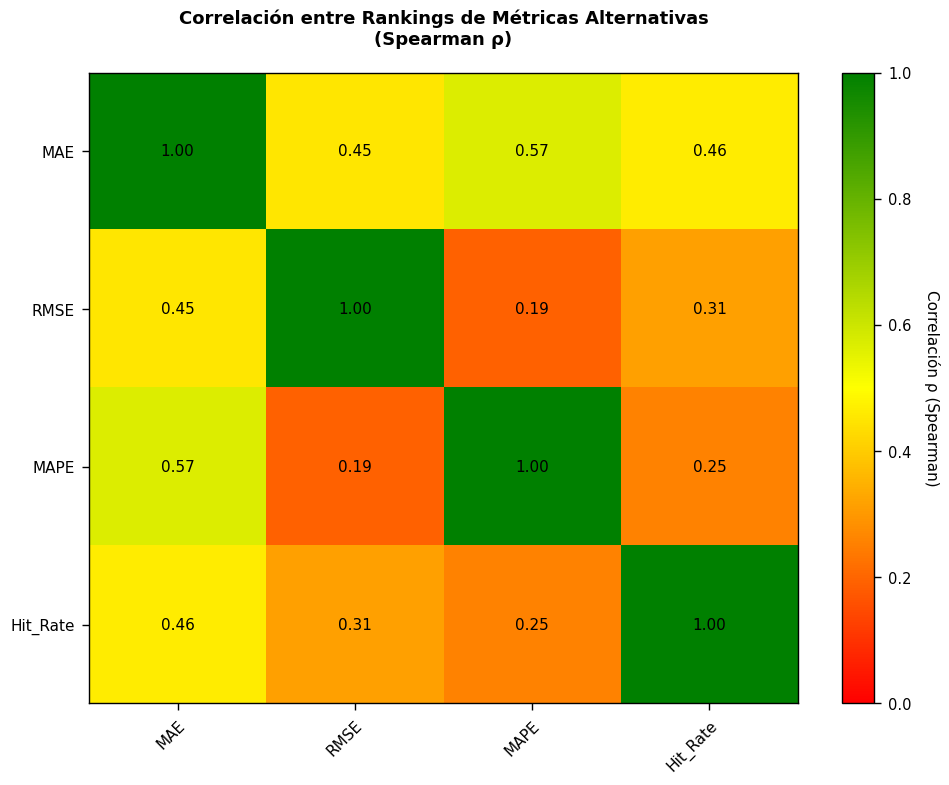


✅ Análisis de métricas alternativas completado


In [ ]:
# ============================================================================
# 6.3. R3A: MÉTRICAS ALTERNATIVAS DE ERROR
# ============================================================================

print("\n" + "="*70)
print("ROBUSTEZ 4: MÉTRICAS ALTERNATIVAS DE ERROR")
print("="*70)

# Horizonte de referencia
h_ref = 12

# Calcular métricas alternativas
df_monthly['error_squared_12m'] = df_monthly['bias_fwd_12m'] ** 2  # Para RMSE
df_monthly['error_abs_pct_12m'] = (df_monthly['bias_fwd_12m'].abs() /
                                    df_monthly['P_PRICE']) * 100  # MAPE

# Hit rate: si la dirección es correcta
df_monthly['direccion_correcta'] = (
    ((df_monthly['bias_0'] > 0) & (df_monthly['bias_fwd_12m'] > 0)) |
    ((df_monthly['bias_0'] < 0) & (df_monthly['bias_fwd_12m'] < 0))
).astype(int)

# Función para calcular métricas por industria
def calcular_metricas_por_industria(df, col_metrica, tipo='median'):
    """Calcula métrica agregada por industria."""
    if tipo == 'median':
        return df.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_metrica].median()
    elif tipo == 'mean':
        return df.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_metrica].mean()
    elif tipo == 'rmse':
        return np.sqrt(df.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_metrica].mean())
    else:
        return df.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_metrica].mean()

# Calcular rankings por cada métrica
metricas = {
    'MAE': ('error_abs_12m', 'median', 'Error Absoluto Mediano'),
    'RMSE': ('error_squared_12m', 'rmse', 'Raíz Error Cuadrático Medio'),
    'MAPE': ('error_abs_pct_12m', 'median', 'Error Porcentual Absoluto Mediano'),
    'Hit_Rate': ('direccion_correcta', 'mean', 'Tasa de Acierto Direccional')
}

rankings_metricas = {}

for nombre_metrica, (columna, tipo, descripcion) in metricas.items():

    if columna not in df_monthly.columns:
        print(f"⚠️ Columna {columna} no existe")
        continue

    # Ranking
    valores = calcular_metricas_por_industria(df_monthly, columna, tipo)

    # Para hit rate, invertir (mayor es mejor)
    if nombre_metrica == 'Hit_Rate':
        ranking = valores.rank(ascending=False)  # Mayor hit rate = mejor (rank bajo)
    else:
        ranking = valores.rank(ascending=False)  # Mayor error = peor (rank alto)

    rankings_metricas[nombre_metrica] = ranking

# Crear DataFrame con todos los rankings
df_metricas = pd.DataFrame(rankings_metricas)
df_metricas['industria'] = df_metricas.index
df_metricas['industria_nombre'] = df_metricas['industria'].map(NOMBRES_INDUSTRIA)

# Reordenar columnas
cols = ['industria', 'industria_nombre'] + list(metricas.keys())
df_metricas = df_metricas[cols]

print("\n📊 RANKINGS POR MÉTRICA ALTERNATIVA")
print("="*70)
print(df_metricas.sort_values('MAE').to_string(index=False))

# Correlaciones entre rankings
print(f"\n🔍 CORRELACIÓN ENTRE RANKINGS (Spearman):")
print("="*70)

correlaciones = []
metricas_lista = list(metricas.keys())

for i, m1 in enumerate(metricas_lista):
    for m2 in metricas_lista[i+1:]:
        if m1 in df_metricas.columns and m2 in df_metricas.columns:
            rho, pval = spearmanr(df_metricas[m1], df_metricas[m2])
            correlaciones.append({
                'Métrica 1': m1,
                'Métrica 2': m2,
                'ρ (Spearman)': rho,
                'p-value': pval
            })

df_corr = pd.DataFrame(correlaciones)
print(df_corr.to_string(index=False))

# Verificar convergencia
print(f"\n✅ CONVERGENCIA DE MÉTRICAS:")
print("-"*70)
rho_promedio = df_corr['ρ (Spearman)'].mean()
print(f"Correlación promedio entre métricas: ρ = {rho_promedio:.3f}")
if rho_promedio > 0.8:
    print("→ ALTA convergencia: Resultados ROBUSTOS a elección de métrica")
elif rho_promedio > 0.6:
    print("→ MODERADA convergencia: Resultados generalmente consistentes")
else:
    print("→ BAJA convergencia: Resultados SENSIBLES a elección de métrica")

# Guardar tablas
guardar_tabla(df_metricas, 'Tabla_Robustez_Metricas_Alternativas')
guardar_tabla(df_corr, 'Tabla_Correlaciones_Metricas')

# Crear matriz de correlación completa
matriz_corr = df_metricas[metricas_lista].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap
cmap = LinearSegmentedColormap.from_list('custom', ['red', 'yellow', 'green'])
im = ax.imshow(matriz_corr, cmap=cmap, vmin=0, vmax=1, aspect='auto')

# Etiquetas
ax.set_xticks(np.arange(len(metricas_lista)))
ax.set_yticks(np.arange(len(metricas_lista)))
ax.set_xticklabels(metricas_lista, fontsize=11)
ax.set_yticklabels(metricas_lista, fontsize=11)

# Rotar etiquetas eje x
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Anotar valores
for i in range(len(metricas_lista)):
    for j in range(len(metricas_lista)):
        text = ax.text(j, i, f'{matriz_corr.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=11)

ax.set_title('Correlación entre Rankings de Métricas Alternativas\n(Spearman ρ)',
             fontsize=13, fontweight='bold', pad=20)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlación ρ (Spearman)', rotation=270, labelpad=20, fontsize=11)

plt.tight_layout()
guardar_figura(fig, 'Fig10_heatmap_metricas')
plt.show()

print("\n✅ Análisis de métricas alternativas completado")


ROBUSTEZ 2: SENSIBILIDAD A OUTLIERS (Winsorización)

📊 COMPARACIÓN: ORIGINAL vs WINSORIZACIÓN
especificacion  gap_pp  kruskal_H  kruskal_p  spearman_rho  spearman_p
      Original 14.3320   638.3043     0.0000        0.2150      0.3626
     Winsor 1% 14.3320   638.4483     0.0000        0.2150      0.3626
     Winsor 5% 14.3320   639.0696     0.0000        0.2150      0.3626

🔍 CAMBIOS RESPECTO A ORIGINAL:
----------------------------------------------------------------------
Gap con Winsor 1%: +0.0% cambio
Gap con Winsor 5%: +0.0% cambio
Persistencia ρ con Winsor 1%: 0.215 (original: 0.215)
Persistencia ρ con Winsor 5%: 0.215 (original: 0.215)

✅ CONCLUSIÓN ROBUSTEZ:
   → Resultados ROBUSTOS a outliers (cambio <10%)
📋 Tabla guardada: resultados_tfg/tablas/Tabla_Robustez_Winsor.xlsx
📊 Figura guardada: resultados_tfg/figuras/Fig09_robustez_winsor.png


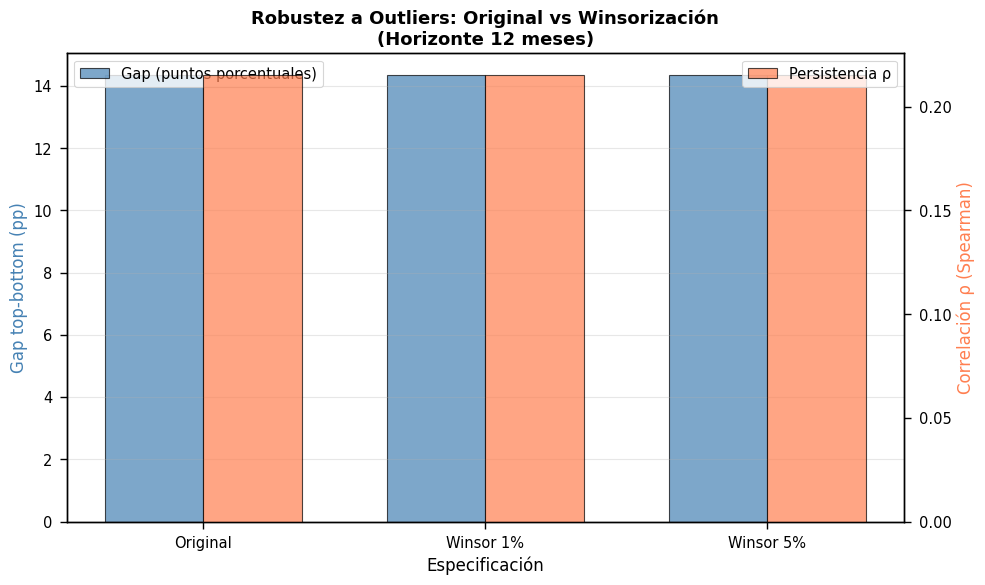


✅ Análisis de sensibilidad a outliers completado


In [ ]:
# ============================================================================
# 6.3. R3B: SENSIBILIDAD A OUTLIERS (Winsorización)
# ============================================================================

print("\n" + "="*70)
print("ROBUSTEZ 2: SENSIBILIDAD A OUTLIERS (Winsorización)")
print("="*70)

# Horizonte de referencia
h_ref = 12
col_error = f'error_abs_{h_ref}m'

# Obtener meses únicos ordenados de df_monthly para definir el punto de corte
meses_unicos = sorted(df_monthly['month'].unique())
mid = len(meses_unicos) // 2
fecha_corte_period = meses_unicos[mid]

# Winsorización al 1% y 5%
# Correctly apply winsorize to non-null values and then reindex to original df_monthly index
non_null_errors = df_monthly[col_error].dropna()
winsorized_1pct_values = mstats.winsorize(non_null_errors.values, limits=[0.01, 0.01])
df_monthly['error_wins_1pct'] = pd.Series(winsorized_1pct_values, index=non_null_errors.index)

non_null_errors = df_monthly[col_error].dropna()
winsorized_5pct_values = mstats.winsorize(non_null_errors.values, limits=[0.05, 0.05])
df_monthly['error_wins_5pct'] = pd.Series(winsorized_5pct_values, index=non_null_errors.index)


# Función para calcular métricas de robustez usando la división temporal fija de la sección 5.2
def calcular_metricas_robustez(df_base, col_error_name, nombre_especificacion, fecha_corte):
    """
    Calcula gap, Kruskal-Wallis y Spearman para una variable de error,
    utilizando la división temporal fija de la sección 5.2.
    """

    # Filter for valid data only for the current error metric
    # This df_filtered retains the full month range but ensures col_error_name is not NaN
    df_filtered = df_base[['FREF_ENTITY_FACTSET_INDUSTRY', 'month', col_error_name]].dropna().copy()

    # --- GAP Calculation ---
    ranking_gap = (
        df_filtered.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_error_name]
        .median()
        .sort_values(ascending=False)
    )
    gap = ranking_gap.iloc[0] - ranking_gap.iloc[-1] if not ranking_gap.empty else np.nan

    # --- Kruskal-Wallis ---
    grupos_kw = [
        grupo[col_error_name].values
        for _, grupo in df_filtered.groupby('FREF_ENTITY_FACTSET_INDUSTRY')
    ]
    grupos_kw = [g for g in grupos_kw if len(np.unique(g)) > 1 and len(g) > 1] # Kruskal needs at least 2 unique values and >1 element

    stat_kw, pval_kw = (kruskal(*grupos_kw) if len(grupos_kw) >= 2 else (np.nan, np.nan))

    # --- Persistencia (using fixed periods from 5.2) ---
    # Define periods using the global fecha_corte_period
    df_periodo1 = df_filtered[df_filtered['month'] < fecha_corte].copy()
    df_periodo2 = df_filtered[df_filtered['month'] >= fecha_corte].copy() # Ensure col_error_name is not NaN

    # Calculate median error for each industry in each period
    # Ensure there's data in the periods before grouping
    rank1_values = df_periodo1.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_error_name].median() if not df_periodo1.empty else pd.Series(dtype=float)
    rank2_values = df_periodo2.groupby('FREF_ENTITY_FACTSET_INDUSTRY')[col_error_name].median() if not df_periodo2.empty else pd.Series(dtype=float)

    # Calculate ranks (ascending=False makes rank 1 the worst, consistent with 5.2 example)
    rank1 = rank1_values.rank(ascending=False)
    rank2 = rank2_values.rank(ascending=False)

    # Intersection of industries present in both periods to calculate Spearman correlation
    industrias_comunes = rank1.index.intersection(rank2.index)

    # Spearman requires at least 2 observations
    rho, pval_rho = (spearmanr(rank1.loc[industrias_comunes], rank2.loc[industrias_comunes])
                     if len(industrias_comunes) >= 2 else (np.nan, np.nan))

    return {
        'especificacion': nombre_especificacion,
        'gap_pp': gap * 100,
        'kruskal_H': stat_kw,
        'kruskal_p': pval_kw,
        'spearman_rho': rho,
        'spearman_p': pval_rho
    }


# Calcular para cada especificación
resultados_wins = []

# Original (sin winsorización)
# Pass df_monthly directly, col_error ensures correct column is picked
resultados_wins.append(calcular_metricas_robustez(df_monthly, col_error, 'Original', fecha_corte_period))

# Winsorización 1%
resultados_wins.append(calcular_metricas_robustez(df_monthly, 'error_wins_1pct', 'Winsor 1%', fecha_corte_period))

# Winsorización 5%
resultados_wins.append(calcular_metricas_robustez(df_monthly, 'error_wins_5pct', 'Winsor 5%', fecha_corte_period))

# Convertir a DataFrame
df_winsor = pd.DataFrame(resultados_wins)

print("\n📊 COMPARACIÓN: ORIGINAL vs WINSORIZACIÓN")
print("="*70)
print(df_winsor.to_string(index=False))

# Cambios relativos
cambio_gap_1 = (df_winsor.loc[1, 'gap_pp'] - df_winsor.loc[0, 'gap_pp']) / df_winsor.loc[0, 'gap_pp'] * 100 if df_winsor.loc[0, 'gap_pp'] != 0 else 0
cambio_gap_5 = (df_winsor.loc[2, 'gap_pp'] - df_winsor.loc[0, 'gap_pp']) / df_winsor.loc[0, 'gap_pp'] * 100 if df_winsor.loc[0, 'gap_pp'] != 0 else 0


print(f"\n🔍 CAMBIOS RESPECTO A ORIGINAL:")
print("-"*70)
print(f"Gap con Winsor 1%: {cambio_gap_1:+.1f}% cambio")
print(f"Gap con Winsor 5%: {cambio_gap_5:+.1f}% cambio")
print(f"Persistencia ρ con Winsor 1%: {df_winsor.loc[1, 'spearman_rho']:.3f} (original: {df_winsor.loc[0, 'spearman_rho']:.3f})")
print(f"Persistencia ρ con Winsor 5%: {df_winsor.loc[2, 'spearman_rho']:.3f} (original: {df_winsor.loc[0, 'spearman_rho']:.3f})")

print(f"\n✅ CONCLUSIÓN ROBUSTEZ:")
if abs(cambio_gap_5) < 10:
    print("   → Resultados ROBUSTOS a outliers (cambio <10%)")
else:
    print("   → Resultados SENSIBLES a outliers (cambio >10%)")

# Guardar tabla
guardar_tabla(df_winsor, 'Tabla_Robustez_Winsor')

# VISUALIZACIÓN: Comparación gráfica
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(df_winsor))
width = 0.35

# Gap
ax.bar(x_pos - width/2, df_winsor['gap_pp'], width,
       label='Gap (puntos porcentuales)', color='steelblue', alpha=0.7, edgecolor='black')

# Persistencia (escalada para visualización)
ax2 = ax.twinx()
ax2.bar(x_pos + width/2, df_winsor['spearman_rho'], width,
        label='Persistencia ρ', color='coral', alpha=0.7, edgecolor='black')

ax.set_xlabel('Especificación', fontsize=12)
ax.set_ylabel('Gap top-bottom (pp)', fontsize=12, color='steelblue')
ax2.set_ylabel('Correlación ρ (Spearman)', fontsize=12, color='coral')
ax.set_title('Robustez a Outliers: Original vs Winsorización\n(Horizonte 12 meses)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_winsor['especificacion'])
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
guardar_figura(fig, 'Fig09_robustez_winsor')
plt.show()

print("\n✅ Análisis de sensibilidad a outliers completado")